In [1]:
# --- Cell 1: Setup imports and directories ---
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sciris as sc
from pathlib import Path

# Set project and results directories
project_dir = Path().absolute()
results_dir = project_dir / ".." / "results" / "vaccination_nona_60"
figure_dir = project_dir / ".." / ".." / "figures"
warnings.filterwarnings("ignore")



NameError: name 'warnings' is not defined

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

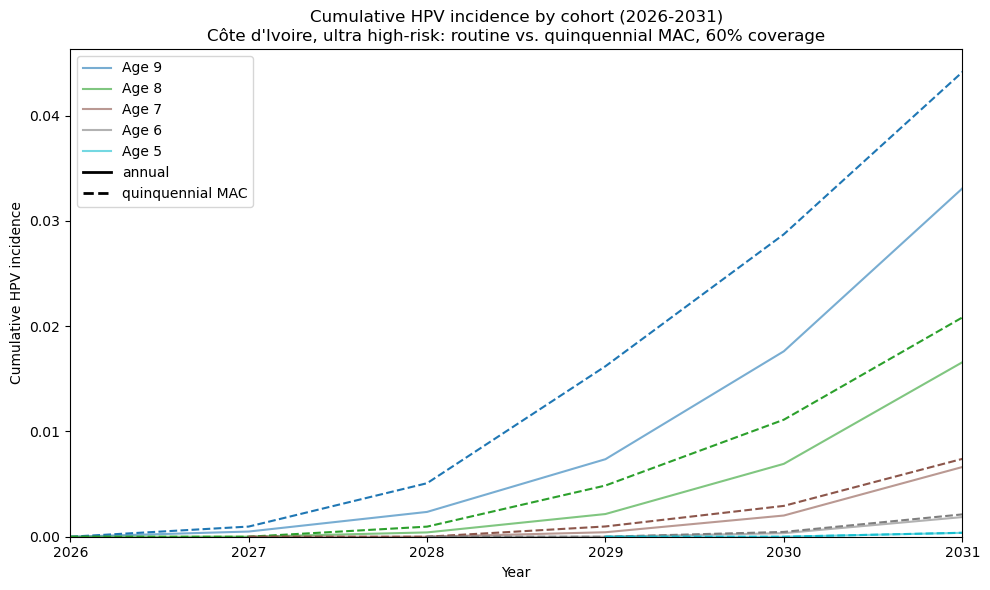

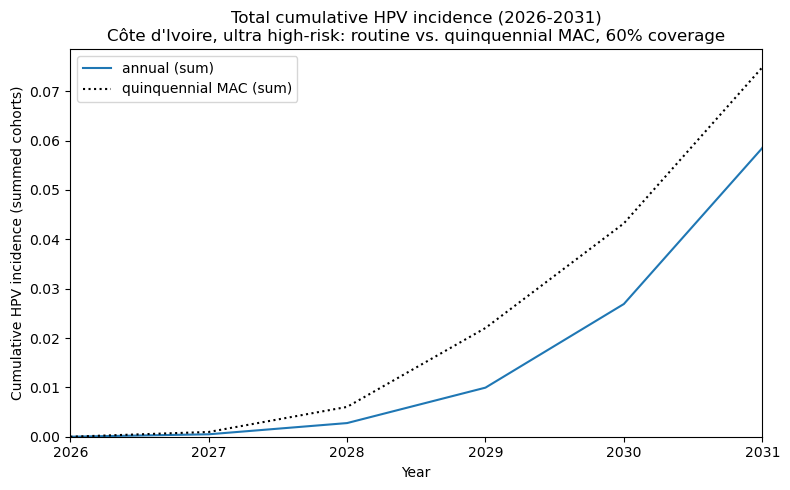

In [3]:
from matplotlib.lines import Line2D

# --- Cell 2: Define enhanced cohort cumulative plotting function ---
def plot_cohort_cumulative_hpv_incidence(country, risk_scenario, scenario1, scenario2, calibration_source="nov06"):
    """
    For girls who are ages 9, 8, 7, 6, 5 in 2026, plot cumulative HPV incidence trajectories for each cohort,
    comparing two vaccination scenarios. X-axis is year, color is cohort, solid/dashed is scenario.
    Generates two plots: one to 2030, one to 2050.
    """
    import matplotlib.cm as cm
    # Determine cohort ages and early plot end year based on scenario2
    scenario2_map = {
        'vx_biennial_9-11': 2,
        'vx_triennial_9-12': 3,
        'vx_quadrennial_9-13': 4,
        'vx_quinquennial_9-14': 5,
    }
    # Default to 5 if not found
    n_cohorts = scenario2_map.get(scenario2, 5)
    cohort_ages_2026 = list(range(9, 9 - n_cohorts, -1))
    end_year_early = 2026 + n_cohorts
    years = np.arange(1960, 2061)
    start_year = 2026
    #end_year_early = 2030
    end_year_lifetime = 2050
    age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
    colors = cm.get_cmap('tab10', len(cohort_ages_2026))

    def get_bin_index(age):
        for i in range(len(age_bin_edges)-1):
            if age_bin_edges[i] <= age < age_bin_edges[i+1]:
                return i
        return None

    def get_cohort_cumulative_trajectory(result, age_2026, end_year):
        incidence_by_age = result.results['hpv_incidence_by_age'].values
        traj = []
        cumsum = 0.0
        for offset in range(end_year - start_year + 1):
            age = age_2026 + offset
            year_idx = start_year - 1960 + offset
            bin_idx = get_bin_index(age)
            if bin_idx is not None and bin_idx > 0 and 0 <= year_idx < incidence_by_age.shape[1]:
                cumsum += incidence_by_age[bin_idx, year_idx]
                traj.append((years[year_idx], cumsum))
        return traj


    def load_result(scenario):
        filename = f"{country}_{scenario}_{risk_scenario}_{calibration_source}.obj"
        filepath = results_dir / filename
        if not filepath.exists():
            print(f"File not found: {filename}")
            return None
        return sc.loadobj(filepath)

    result1 = load_result(scenario1)
    result2 = load_result(scenario2)
    if result1 is None or result2 is None:
        print("Missing results for one or both scenarios.")
        return
    if risk_scenario == "NAT":
        risk_scenario_title = "national"
    elif risk_scenario == "HR":
        risk_scenario_title = "high-risk"
    elif risk_scenario == "UHR":
        risk_scenario_title = "ultra high-risk"
    else:
        risk_scenario_title = risk_scenario

    if country == "cote_d_ivoire":
        country_title = "Côte d'Ivoire"
    elif country == "zambia":
        country_title = 'Zambia'
    
    # Plot for early years (to 2030)
    # Compute cumulative trajectories out to end_year_lifetime for all cohorts and both scenarios
    cohort_trajs1 = []
    cohort_trajs2 = []
    for age_2026 in cohort_ages_2026:
        traj1 = get_cohort_cumulative_trajectory(result1, age_2026, end_year_lifetime)
        traj2 = get_cohort_cumulative_trajectory(result2, age_2026, end_year_lifetime)
        if len(traj2) > n_cohorts:
            diff = traj2[n_cohorts][1] - traj1[n_cohorts][1]
            for i in range(n_cohorts+1, len(traj2)):
                traj2[i] = (traj2[i][0], traj1[i][1] + diff)
        cohort_trajs1.append(traj1)
        cohort_trajs2.append(traj2)

    # Extract the interval word from scenario2 (e.g., "biennial", "triennial", etc.)
    scenario2_parts = scenario2.split('_')
    interval_word = scenario2_parts[1] if len(scenario2_parts) > 1 else scenario2

    # Plot for early years (to end_year_early)
    # Plot for lifetime (to end_year_lifetime)
    plt.figure(figsize=(10, 6))
    for idx, (traj1, traj2) in enumerate(zip(cohort_trajs1, cohort_trajs2)):
        if traj1:
            plt.plot([t[0] for t in traj1], [t[1] for t in traj1], color=colors(idx), linestyle='-', alpha=0.6, label=f"Age {cohort_ages_2026[idx]}")
        if traj2:
            plt.plot([t[0] for t in traj2], [t[1] for t in traj2], color=colors(idx), linestyle='--', label=f"Age {cohort_ages_2026[idx]}")
    plt.xlabel("Year")
    plt.ylabel("Cumulative HPV incidence")
    plt.title(f"Cumulative HPV incidence by cohort (2026-{end_year_lifetime})\n{country_title}, {risk_scenario_title}: routine vs. {interval_word} MAC, 60% coverage")
    handles, labels = plt.gca().get_legend_handles_labels()
    filtered_handles = [h for i, h in enumerate(handles) if i % 2 == 0]
    filtered_labels = [l for i, l in enumerate(labels) if i % 2 == 0]
    custom_lines = [
        Line2D([0], [0], color='black', linestyle='-', lw=2, label='annual'),
        Line2D([0], [0], color='black', linestyle='--', lw=2, label=f'{interval_word} MAC')
    ]
    plt.legend(filtered_handles + custom_lines, filtered_labels + ['annual', f'{interval_word} MAC'])
    plt.tight_layout()
    plt.xlim(start_year, end_year_lifetime)
    #plt.show()
    fname_lifetime = f"cumulative_incidence_2026-{end_year_lifetime}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / "60" / fname_lifetime, dpi=300)

    # Zoom into early years (to end_year_early) and save again
    plt.xlim(start_year, end_year_early)
    # Adjust ylim to fit the data in the zoomed-in x range
    # Find the maximum y value within the zoomed-in x range for all trajectories
    max_y = 0
    for traj1, traj2 in zip(cohort_trajs1, cohort_trajs2):
        y1 = [t[1] for t in traj1 if start_year <= t[0] <= end_year_early]
        y2 = [t[1] for t in traj2 if start_year <= t[0] <= end_year_early]
        if y1:
            max_y = max(max_y, max(y1))
        if y2:
            max_y = max(max_y, max(y2))
    plt.ylim(0, max_y * 1.05 if max_y > 0 else 1)
    plt.title(f"Cumulative HPV incidence by cohort (2026-{end_year_early})\n{country_title}, {risk_scenario_title}: routine vs. {interval_word} MAC, 60% coverage")
    plt.tight_layout()
    #plt.show()
    fname_early = f"cumulative_incidence_2026-{end_year_early}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / "60" / fname_early, dpi=300)

    # --- Plot summed cumulative incidence for all cohorts together ---

    # Sum cumulative incidence across all cohorts for each scenario
    summed_traj1 = None
    summed_traj2 = None
    for traj1, traj2 in zip(cohort_trajs1, cohort_trajs2):
        y1 = np.array([t[1] for t in traj1])
        y2 = np.array([t[1] for t in traj2])
        x1 = np.array([t[0] for t in traj1])
        x2 = np.array([t[0] for t in traj2])
        if summed_traj1 is None:
            summed_traj1 = y1
            summed_x1 = x1
        else:
            summed_traj1 = summed_traj1 + np.interp(summed_x1, x1, y1)
        if summed_traj2 is None:
            summed_traj2 = y2
            summed_x2 = x2
        else:
            summed_traj2 = summed_traj2 + np.interp(summed_x2, x2, y2)

    # Plot for lifetime (to end_year_lifetime)
    plt.figure(figsize=(8, 5))
    plt.plot(summed_x1, summed_traj1, color='tab:blue', linestyle='-', label='annual (sum)')
    plt.plot(summed_x2, summed_traj2, color='k', linestyle=':', label=f'{interval_word} MAC (sum)')
    plt.xlabel("Year")
    plt.ylabel("Cumulative HPV incidence (summed cohorts)")
    plt.title(f"Total cumulative HPV incidence (2026-{end_year_lifetime})\n{country_title}, {risk_scenario_title}: routine vs. {interval_word} MAC, 60% coverage")
    plt.legend()
    plt.tight_layout()
    plt.xlim(start_year, end_year_lifetime)
    #plt.show()
    fname_sum_lifetime = f"cumulative_incidence_sum_2026-{end_year_lifetime}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / "60" / fname_sum_lifetime, dpi=300)

    # Plot for early years (to end_year_early)
    plt.xlim(start_year, end_year_early)
    # Adjust ylim to fit the data in the zoomed-in x range
    mask1 = (summed_x1 >= start_year) & (summed_x1 <= end_year_early)
    mask2 = (summed_x2 >= start_year) & (summed_x2 <= end_year_early)
    max_y_sum = 0
    if np.any(mask1):
        max_y_sum = max(max_y_sum, np.max(summed_traj1[mask1]))
    if np.any(mask2):
        max_y_sum = max(max_y_sum, np.max(summed_traj2[mask2]))
    plt.ylim(0, max_y_sum * 1.05 if max_y_sum > 0 else 1)
    plt.title(f"Total cumulative HPV incidence (2026-{end_year_early})\n{country_title}, {risk_scenario_title}: routine vs. {interval_word} MAC, 60% coverage")
    plt.tight_layout()
    #plt.show()
    fname_sum_early = f"cumulative_incidence_sum_2026-{end_year_early}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / "60" / fname_sum_early, dpi=300)

country = 'cote_d_ivoire'
risk_scenario = 'UHR'
scenario = "vx_quinquennial_9-14"
plot_cohort_cumulative_hpv_incidence(country, risk_scenario, "vx_annual_9-10", scenario, calibration_source="nov06")

Processing cote_d_ivoire, NAT, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, NAT, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, NAT, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, NAT, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2037390375.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

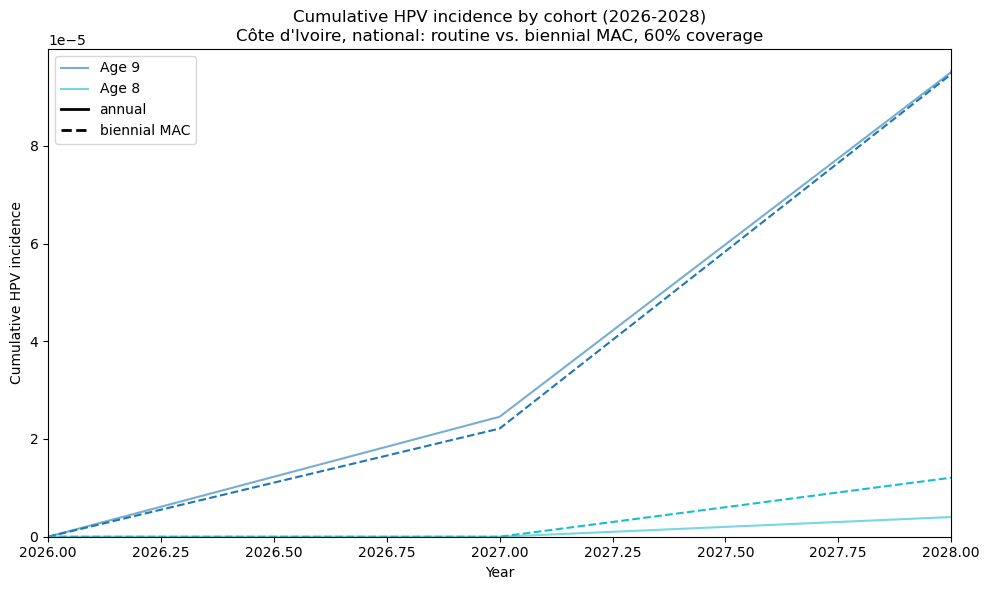

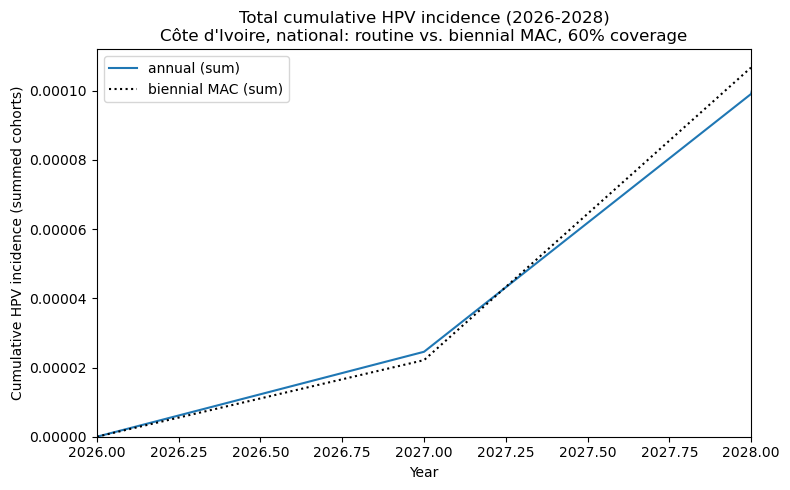

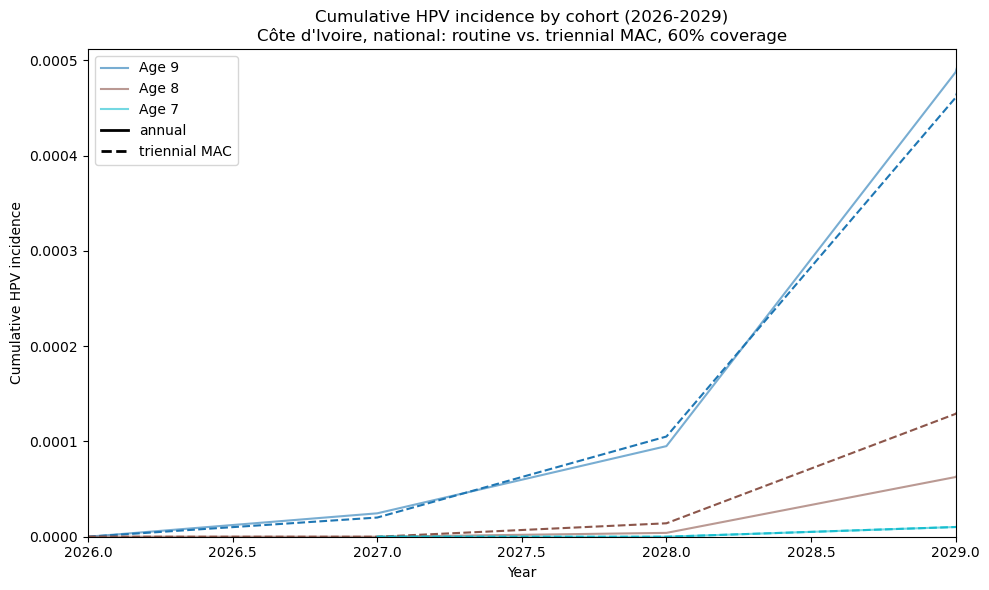

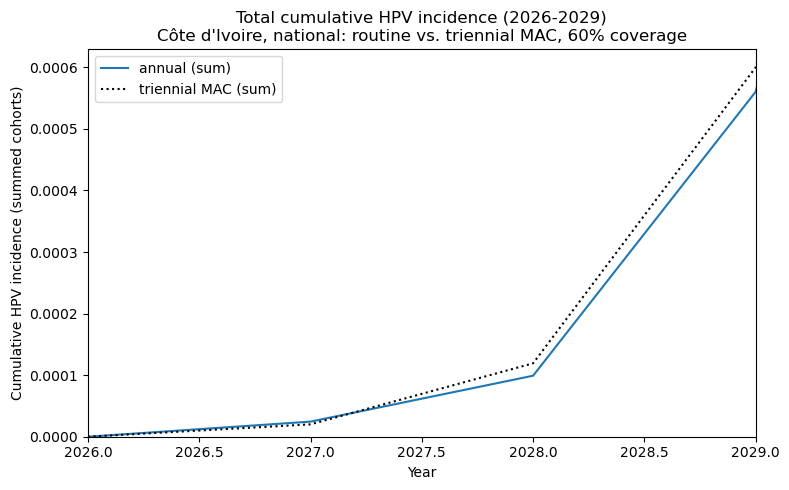

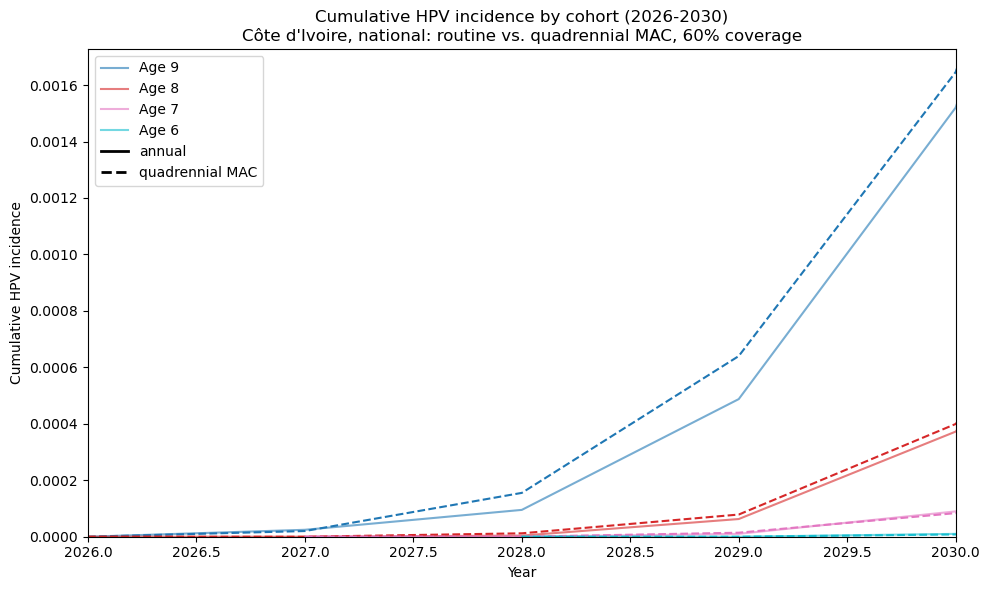

...

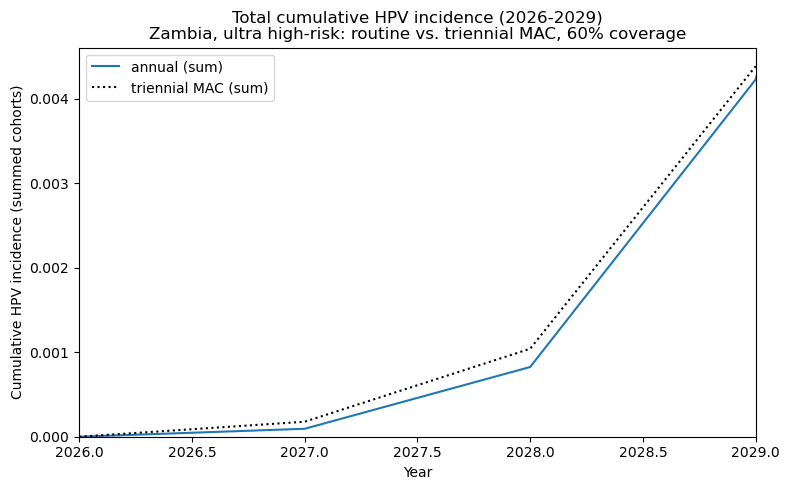

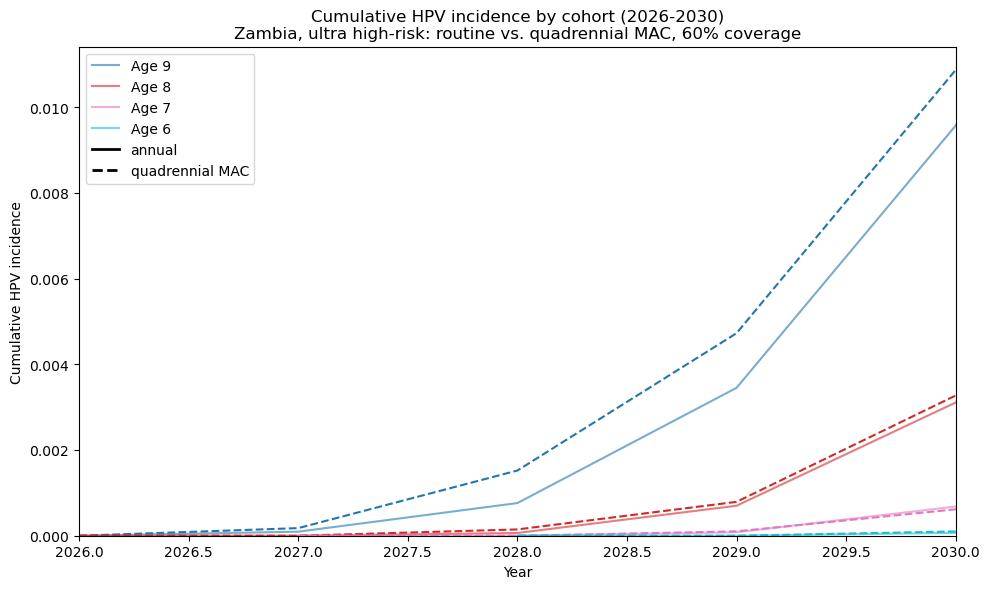

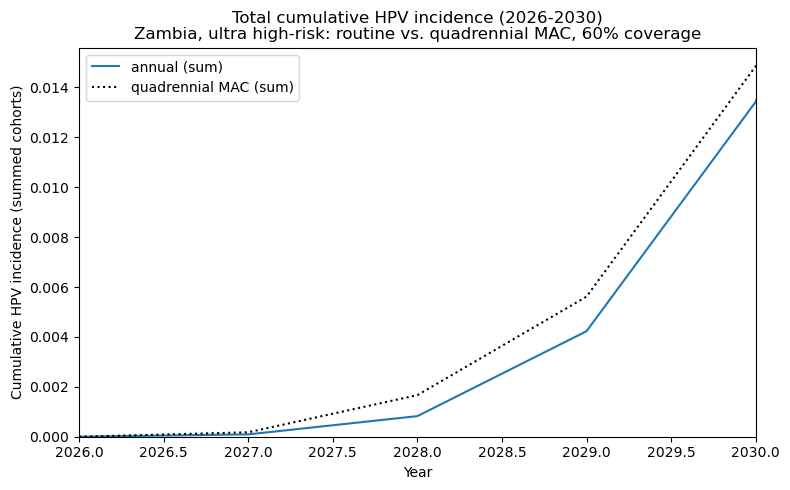

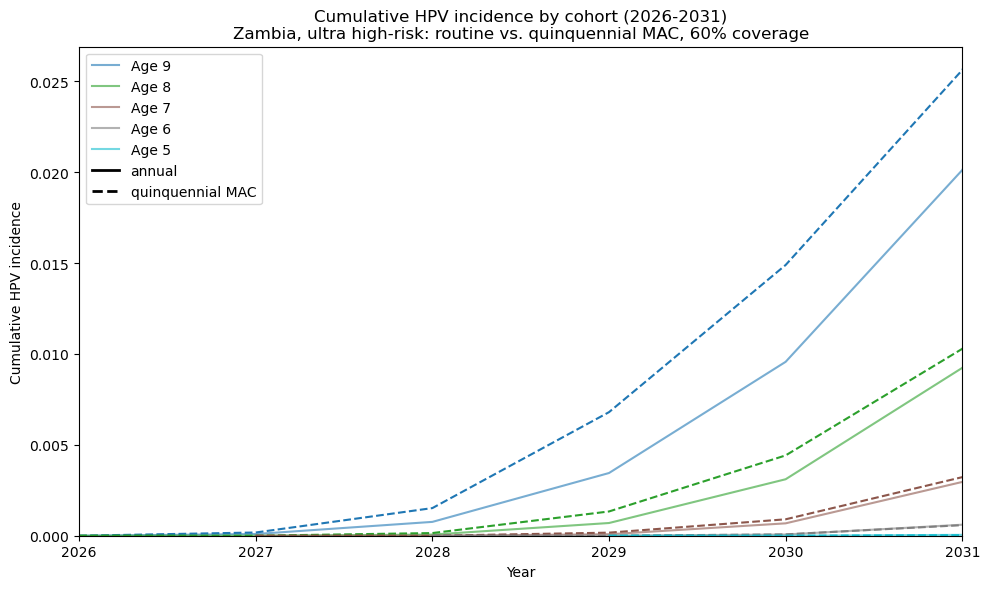

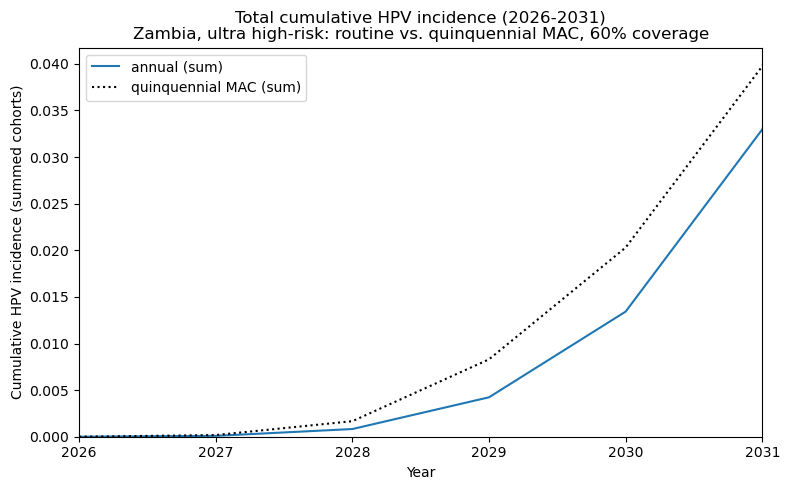

In [4]:
for country in ["cote_d_ivoire", "zambia"]:
    for risk_scenario in ["NAT", "HR", "UHR"]:
        for scenario in ["vx_biennial_9-11", "vx_triennial_9-12", "vx_quadrennial_9-13", "vx_quinquennial_9-14"]:
            print(f"Processing {country}, {risk_scenario}, {scenario}")
            print("Generating cumulative HPV incidence plots...")
            plot_cohort_cumulative_hpv_incidence(
                country=country,
                risk_scenario=risk_scenario,
                scenario1="vx_annual_9-10",
                scenario2=scenario,
                calibration_source="nov06"
        )

In [11]:
from matplotlib.lines import Line2D

# --- Cell 2: Define enhanced cohort cumulative plotting function ---
def plot_cohort_cumulative_hpv_incidence_compare_coverage(country, risk_scenario, scenario1, scenario2, cov1, cov2, calibration_source="nov06"):
    """
    For girls who are ages 9, 8, 7, 6, 5 in 2026, plot cumulative HPV incidence trajectories for each cohort,
    comparing two vaccination scenarios. X-axis is year, color is cohort, solid/dashed is scenario.
    Generates two plots: one to 2030, one to 2050.
    """
    import matplotlib.cm as cm
    # Determine cohort ages and early plot end year based on scenario2
    scenario2_map = {
        'vx_biennial_9-11': 2,
        'vx_triennial_9-12': 3,
        'vx_quadrennial_9-13': 4,
        'vx_quinquennial_9-14': 5,
    }
    # Default to 5 if not found
    if country == "cote_d_ivoire":
        country_title = "Côte d'Ivoire"
    elif country == "zambia":
        country_title = 'Zambia'
    n_cohorts = scenario2_map.get(scenario2, 5)
    cohort_ages_2026 = list(range(9, 9 - n_cohorts, -1))
    end_year_early = 2026 + n_cohorts 
    years = np.arange(1960, 2061)
    start_year = 2026
    #end_year_early = 2030
    end_year_lifetime = 2050
    age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
    colors = cm.get_cmap('tab10', len(cohort_ages_2026))
    results_dir1 = project_dir / ".." / "results" / (f"vaccination_nona_{cov1}")
    results_dir2 = project_dir / ".." / "results" / (f"vaccination_nona_{cov2}")

    def get_bin_index(age):
        for i in range(len(age_bin_edges)-1):
            if age_bin_edges[i] <= age < age_bin_edges[i+1]:
                return i
        return None

    def get_cohort_cumulative_trajectory(result, age_2026, end_year):
        incidence_by_age = result.results['hpv_incidence_by_age'].values
        traj = []
        cumsum = 0.0
        for offset in range(end_year - start_year + 1):
            age = age_2026 + offset
            year_idx = start_year - 1960 + offset
            bin_idx = get_bin_index(age)
            if bin_idx is not None and bin_idx > 0 and 0 <= year_idx < incidence_by_age.shape[1]:
                cumsum += incidence_by_age[bin_idx, year_idx]
                traj.append((years[year_idx], cumsum))
        return traj


    def load_result(result_dir, scenario):
        filename = f"{country}_{scenario}_{risk_scenario}_{calibration_source}.obj"
        filepath = result_dir / filename
        if not filepath.exists():
            print(f"File not found: {filename}")
            return None
        return sc.loadobj(filepath)

    result1 = load_result(results_dir1, scenario1)
    result2 = load_result(results_dir2, scenario2)
    if result1 is None or result2 is None:
        print("Missing results for one or both scenarios.")
        return

    # Plot for early years (to 2030)
    # Compute cumulative trajectories out to end_year_lifetime for all cohorts and both scenarios
    cohort_trajs1 = []
    cohort_trajs2 = []
    for age_2026 in cohort_ages_2026:
        traj1 = get_cohort_cumulative_trajectory(result1, age_2026, end_year_lifetime)
        traj2 = get_cohort_cumulative_trajectory(result2, age_2026, end_year_lifetime)
        cohort_trajs1.append(traj1)
        cohort_trajs2.append(traj2)

    # Extract the interval word from scenario2 (e.g., "biennial", "triennial", etc.)
    scenario2_parts = scenario2.split('_')
    interval_word = scenario2_parts[1] if len(scenario2_parts) > 1 else scenario2
    if risk_scenario == "NAT":
        risk_scenario_title = "national"
    elif risk_scenario == "HR":
        risk_scenario_title = "high-risk"
    elif risk_scenario == "UHR":
        risk_scenario_title = "ultra high-risk"
    else:
        risk_scenario_title = risk_scenario
    # Plot for early years (to end_year_early)
    # Plot for lifetime (to end_year_lifetime)
    plt.figure(figsize=(10, 6))
    for idx, (traj1, traj2) in enumerate(zip(cohort_trajs1, cohort_trajs2)):
        if traj1:
            plt.plot([t[0] for t in traj1], [t[1] for t in traj1], color=colors(idx), linestyle='-', alpha=0.6, label=f"Age {cohort_ages_2026[idx]}")
        if traj2:
            plt.plot([t[0] for t in traj2], [t[1] for t in traj2], color=colors(idx), linestyle='--', label=f"Age {cohort_ages_2026[idx]}")
    plt.xlabel("Year")
    plt.ylabel("Cumulative HPV incidence")
    plt.title(f"Cumulative HPV incidence by cohort (2026-{end_year_lifetime})\n{country_title}, {risk_scenario_title}: routine {cov1}% coverage vs. {interval_word} MAC, {cov2}% coverage")
    handles, labels = plt.gca().get_legend_handles_labels()
    filtered_handles = [h for i, h in enumerate(handles) if i % 2 == 0]
    filtered_labels = [l for i, l in enumerate(labels) if i % 2 == 0]
    custom_lines = [
        Line2D([0], [0], color='black', linestyle='-', lw=2, label='annual'),
        Line2D([0], [0], color='black', linestyle='--', lw=2, label=f'{interval_word} MAC')
    ]
    plt.legend(filtered_handles + custom_lines, filtered_labels + ['annual', f'{interval_word} MAC'])
    plt.tight_layout()
    plt.xlim(start_year, end_year_lifetime)
    #plt.show()
    fname_lifetime = f"cumulative_incidence_2026-{end_year_lifetime}_{cov1}_{cov2}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / f"{cov1}_{cov2}"/ fname_lifetime, dpi=300)

    # Zoom into early years (to end_year_early) and save again
    plt.xlim(start_year, end_year_early)
    # Adjust ylim to fit the data in the zoomed-in x range
    # Find the maximum y value within the zoomed-in x range for all trajectories
    max_y = 0
    for traj1, traj2 in zip(cohort_trajs1, cohort_trajs2):
        y1 = [t[1] for t in traj1 if start_year <= t[0] <= end_year_early]
        y2 = [t[1] for t in traj2 if start_year <= t[0] <= end_year_early]
        if y1:
            max_y = max(max_y, max(y1))
        if y2:
            max_y = max(max_y, max(y2))
    plt.ylim(0, max_y * 1.05 if max_y > 0 else 1)
    plt.title(f"Cumulative HPV incidence by cohort (2026-{end_year_early})\n{country_title}, {risk_scenario_title}: routine {cov1}% coverage vs. {interval_word} MAC, {cov2}% coverage")
    plt.tight_layout()
    #plt.show()
    fname_early = f"cumulative_incidence_2026-{end_year_early}_{cov1}_{cov2}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / f"{cov1}_{cov2}" / fname_early, dpi=300)

    # --- Plot summed cumulative incidence for all cohorts together ---

    # Sum cumulative incidence across all cohorts for each scenario
    summed_traj1 = None
    summed_traj2 = None
    for traj1, traj2 in zip(cohort_trajs1, cohort_trajs2):
        y1 = np.array([t[1] for t in traj1])
        y2 = np.array([t[1] for t in traj2])
        x1 = np.array([t[0] for t in traj1])
        x2 = np.array([t[0] for t in traj2])
        if summed_traj1 is None:
            summed_traj1 = y1
            summed_x1 = x1
        else:
            summed_traj1 = summed_traj1 + np.interp(summed_x1, x1, y1)
        if summed_traj2 is None:
            summed_traj2 = y2
            summed_x2 = x2
        else:
            summed_traj2 = summed_traj2 + np.interp(summed_x2, x2, y2)

    # Plot for lifetime (to end_year_lifetime)
    plt.figure(figsize=(8, 5))
    plt.plot(summed_x1, summed_traj1, color='tab:blue', linestyle='-', label='annual (sum)')
    plt.plot(summed_x2, summed_traj2, color='k', linestyle=':', label=f'{interval_word} MAC (sum)')
    plt.xlabel("Year")
    plt.ylabel("Cumulative HPV incidence (summed cohorts)")
    plt.title(f"Total cumulative HPV incidence (2026-{end_year_lifetime})\n{country_title}, {risk_scenario_title}: routine {cov1}% coverage vs. {interval_word} MAC, {cov2}% coverage")
    plt.legend()
    plt.tight_layout()
    plt.xlim(start_year, end_year_lifetime)
    #plt.show()
    fname_sum_lifetime = f"cumulative_incidence_sum_2026-{end_year_lifetime}_{cov1}_{cov2}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / f"{cov1}_{cov2}"/ fname_sum_lifetime, dpi=300)

    # Plot for early years (to end_year_early)
    plt.xlim(start_year, end_year_early)
    # Adjust ylim to fit the data in the zoomed-in x range
    mask1 = (summed_x1 >= start_year) & (summed_x1 <= end_year_early)
    mask2 = (summed_x2 >= start_year) & (summed_x2 <= end_year_early)
    max_y_sum = 0
    if np.any(mask1):
        max_y_sum = max(max_y_sum, np.max(summed_traj1[mask1]))
    if np.any(mask2):
        max_y_sum = max(max_y_sum, np.max(summed_traj2[mask2]))
    plt.ylim(0, max_y_sum * 1.05 if max_y_sum > 0 else 1)
    plt.title(f"Total cumulative HPV incidence (2026-{end_year_early})\n{country_title}, {risk_scenario_title}: routine {cov1}% coverage vs. {interval_word} MAC, {cov2}% coverage")
    plt.tight_layout()
    #plt.show()
    fname_sum_early = f"cumulative_incidence_sum_2026-{end_year_early}_{cov1}_{cov2}_{interval_word}_{country}_{risk_scenario}.png"
    plt.savefig(figure_dir / f"{cov1}_{cov2}"/ fname_sum_early, dpi=300)

country = 'cote_d_ivoire'
risk_scenario = 'UHR'
scenario = "vx_quinquennial_9-14"
#plot_cohort_cumulative_hpv_incidence_compare_coverage(country, risk_scenario, "vx_annual_9-10", scenario, '60', '60', calibration_source="nov06")

Processing cote_d_ivoire, NAT, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, NAT, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, NAT, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, NAT, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, HR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing cote_d_ivoire, UHR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, NAT, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, HR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_biennial_9-11
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_triennial_9-12
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_quadrennial_9-13
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

Processing zambia, UHR, vx_quinquennial_9-14
Generating cumulative HPV incidence plots...


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_78117/2320063885.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

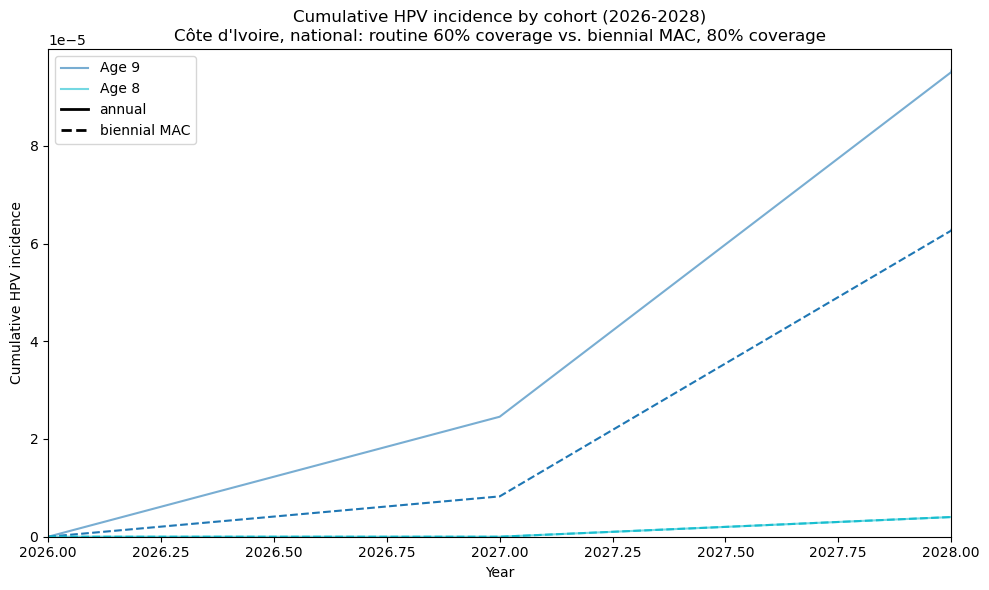

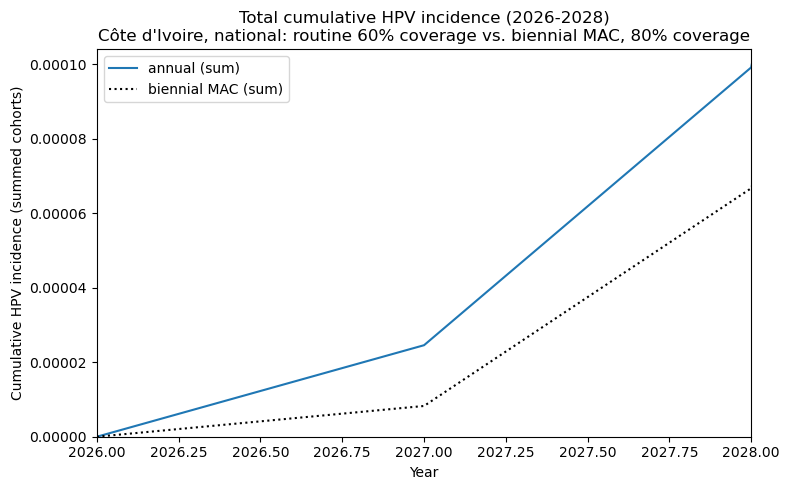

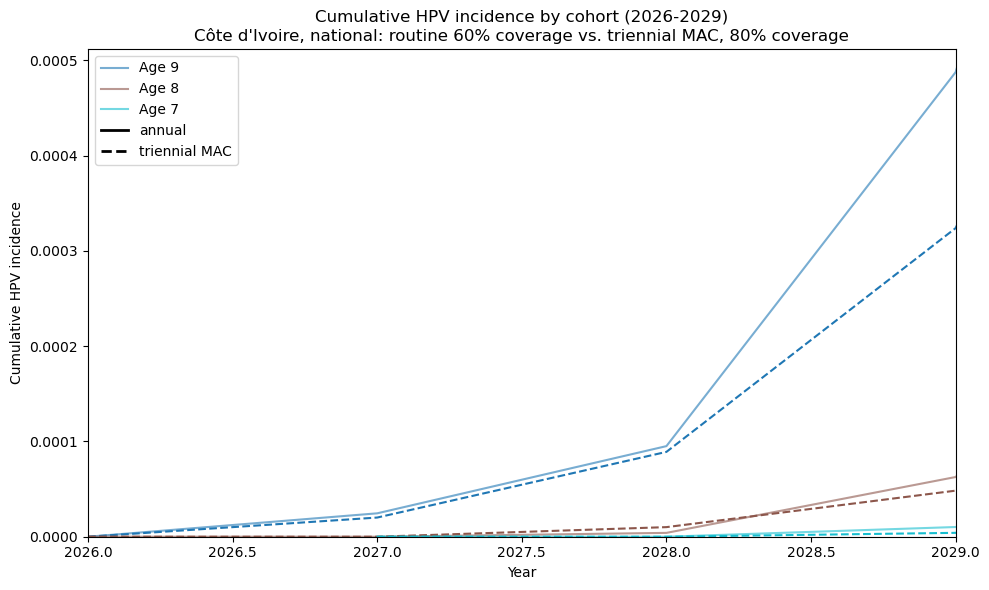

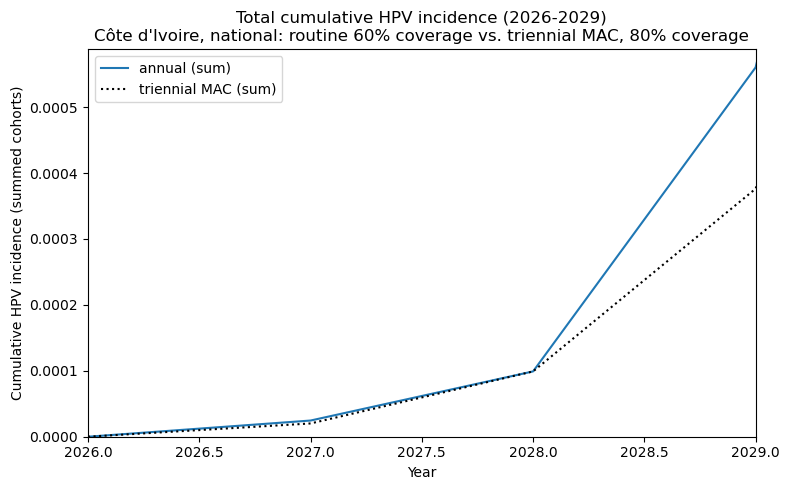

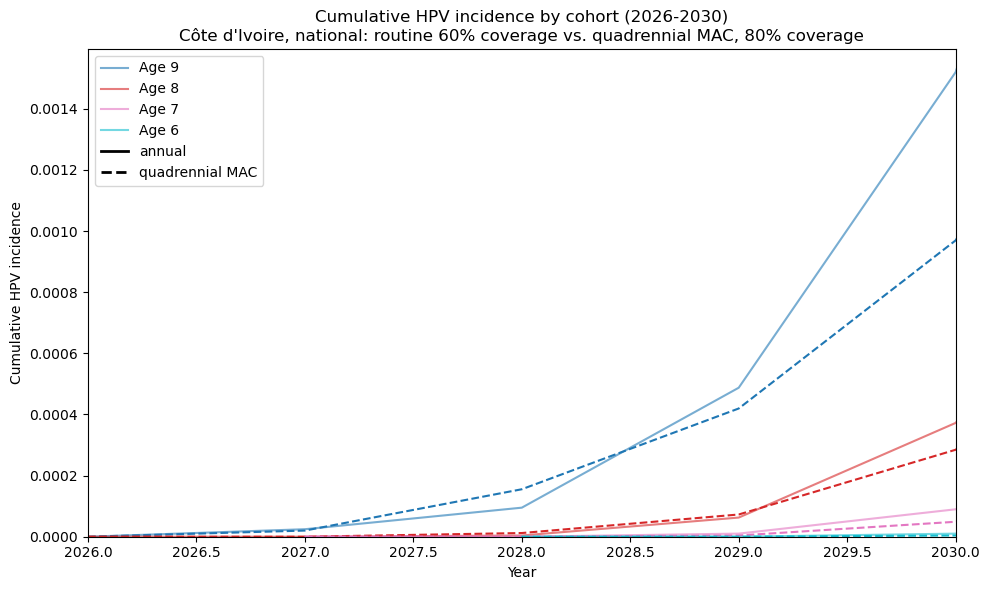

...

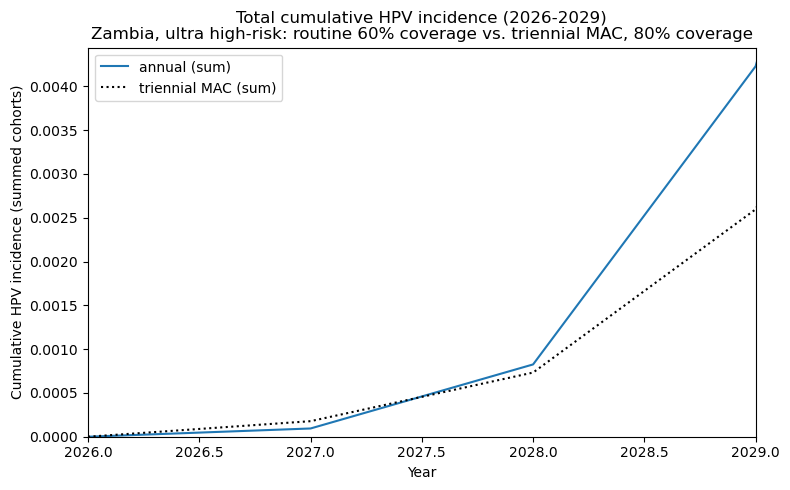

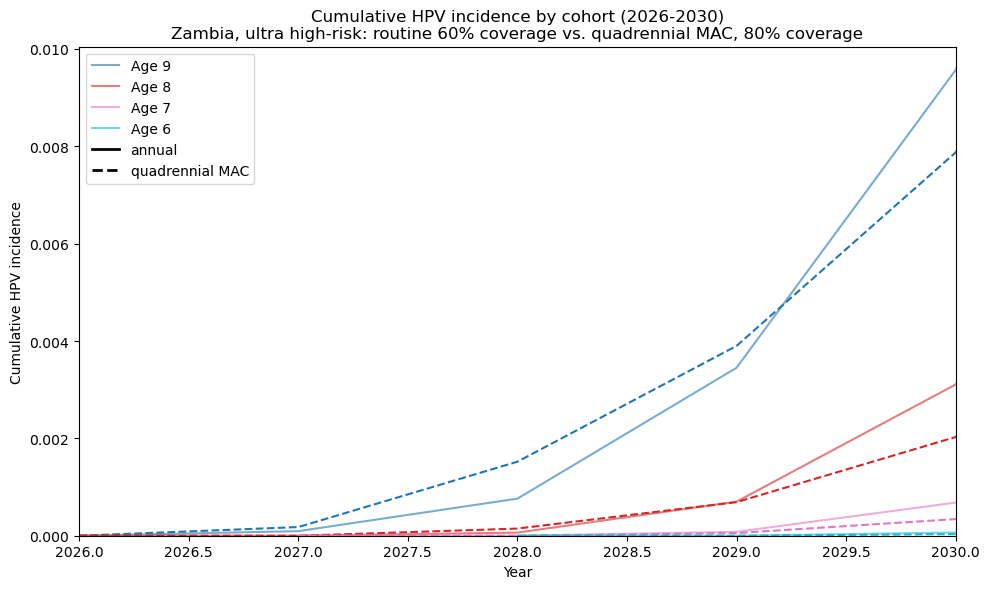

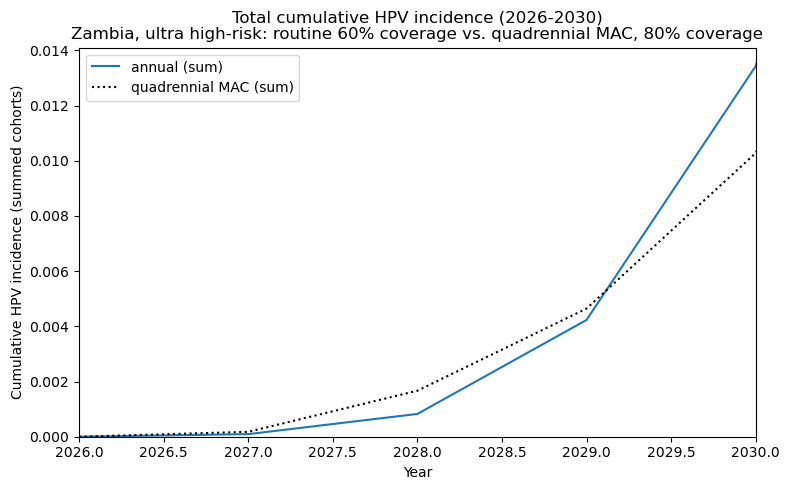

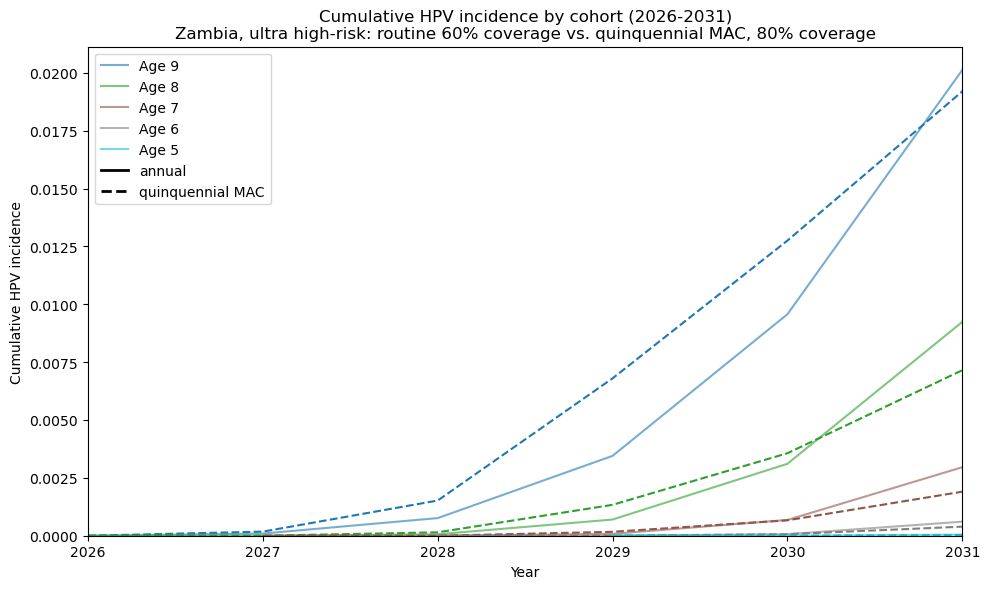

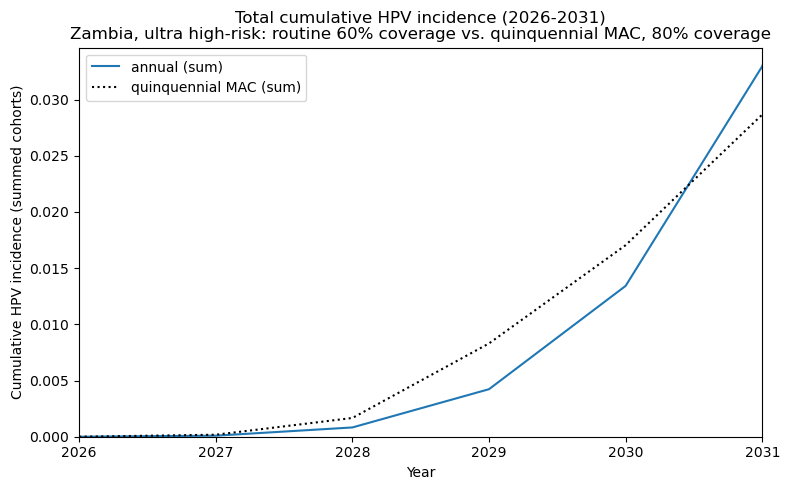

In [12]:
for cov in ['80']:
    for country in ["cote_d_ivoire", "zambia"]:
        for risk_scenario in ["NAT", "HR", "UHR"]:
            for scenario in ["vx_biennial_9-11", "vx_triennial_9-12", "vx_quadrennial_9-13", "vx_quinquennial_9-14"]:
                print(f"Processing {country}, {risk_scenario}, {scenario}")
                print("Generating cumulative HPV incidence plots...")
                plot_cohort_cumulative_hpv_incidence_compare_coverage(
                    country=country,
                    risk_scenario=risk_scenario,
                    scenario1="vx_annual_9-10",
                    scenario2=scenario,
                    cov1='60',
                    cov2=cov,
                    calibration_source="nov06"
            )

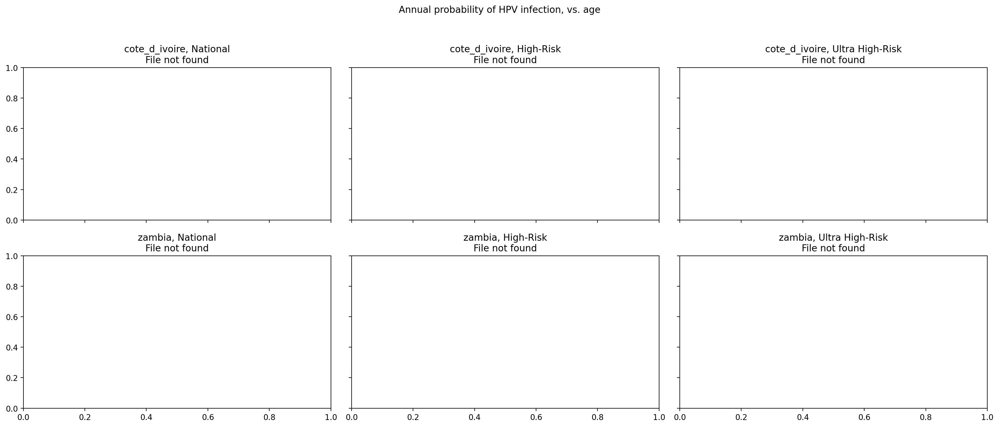

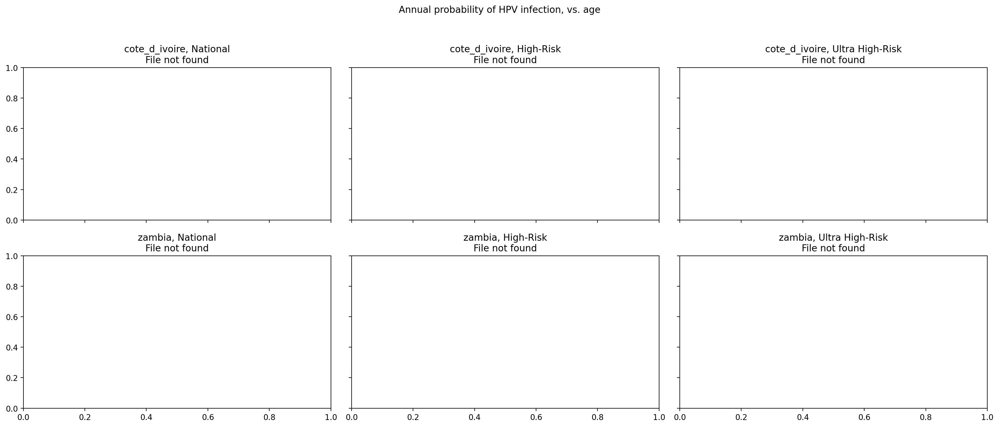

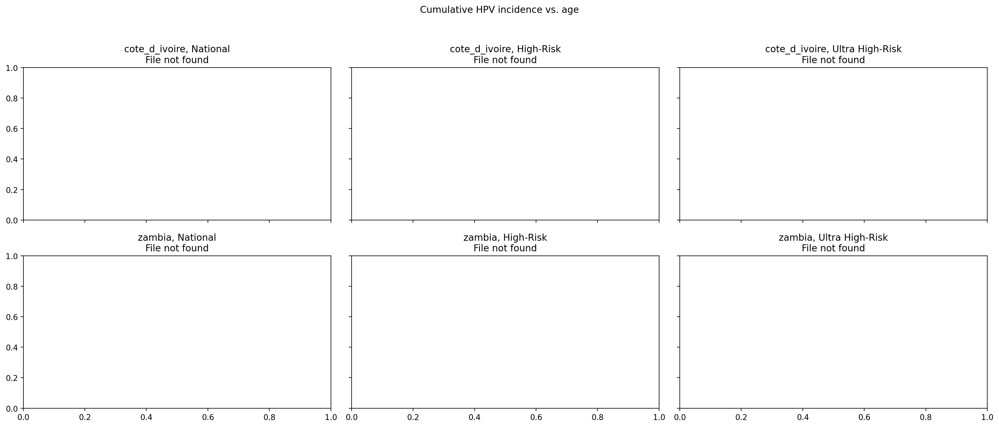

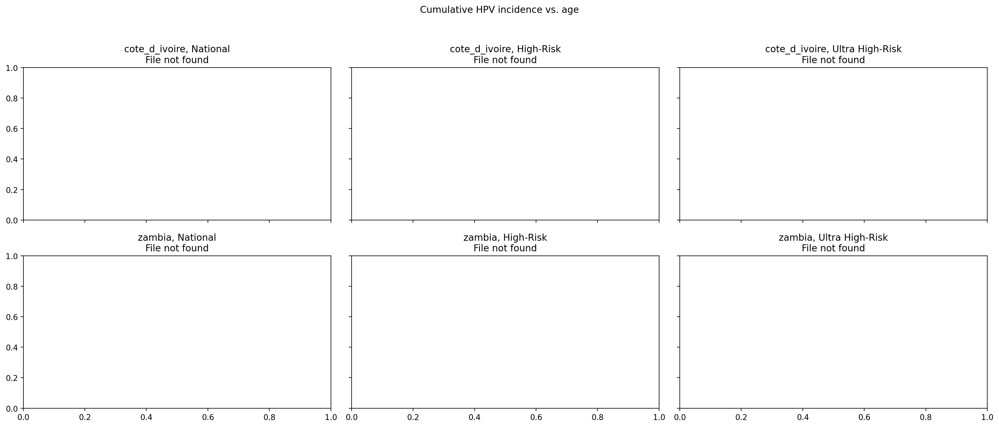

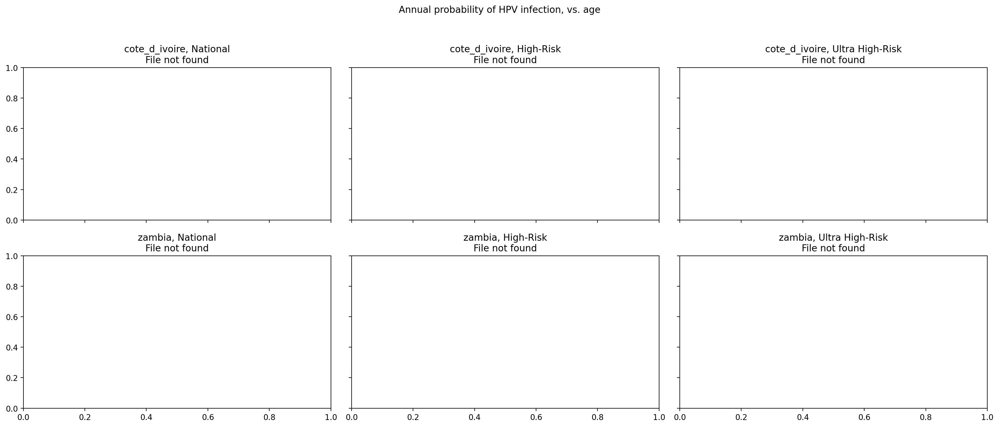

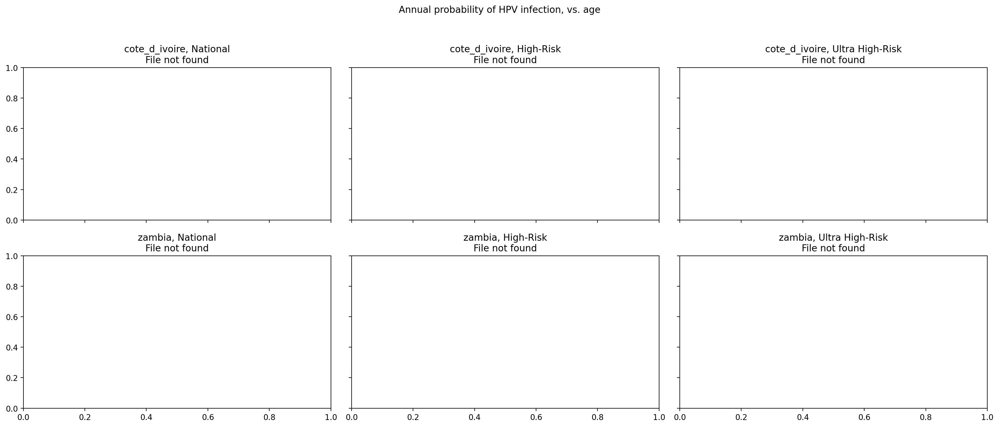

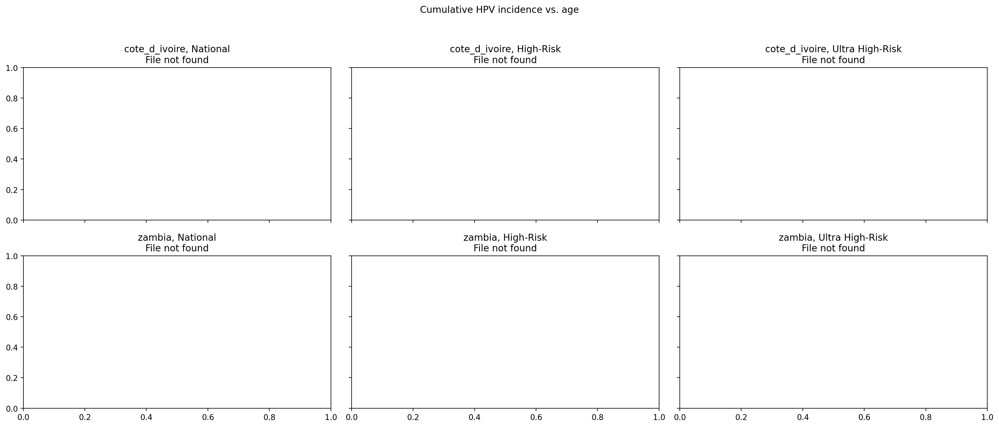

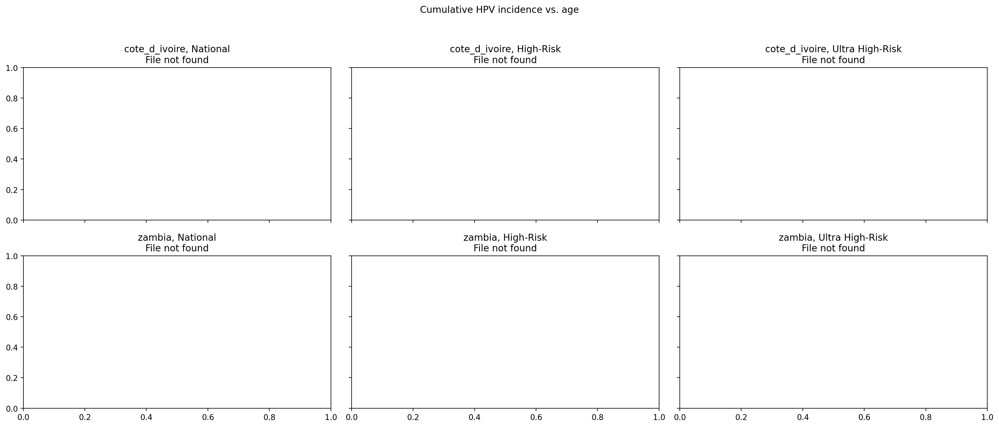

In [10]:
from scipy.ndimage import gaussian_filter1d

# --- Cell 4: Annual and cumulative incidence for 2025 age-9 cohort, by country and risk ---
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def plot_annual_and_cumulative_for_2025_age9():
    countries = ['cote_d_ivoire', 'zambia']
    risks = ['NAT', 'HR', 'UHR']
    risk_labels = {'NAT': 'National', 'HR': 'High-Risk', 'UHR': 'Ultra High-Risk'}
    scenario = '60'
    calibration_source = 'nov06'
    start_year = 2025
    cohort_start_age = 9
    years = np.arange(1960, 2061)
    age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
    max_age = 44  # for zoomed out
    zoom_ages = [(9, 13), (9, 44)]

    def get_bin_index(age):
        for i in range(len(age_bin_edges)-1):
            if age_bin_edges[i] <= age < age_bin_edges[i+1]:
                return i
        return None

    nrows, ncols = 2, 3
    for (age_min, age_max) in zoom_ages:
        # Annual incidence panels (linear and log)
        for logy in [False, True]:
            fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8), sharex=True, sharey=True, dpi=200)
            scale = 'log' if logy else 'linear'
            fig.suptitle("Annual probability of HPV infection, vs. age")
            for i, country in enumerate(countries):
                for j, risk in enumerate(risks):
                    ax = axes[i, j]
                    filename = f"{country}_{scenario}_{risk}_{calibration_source}.obj"
                    filepath = results_dir / filename
                    if not filepath.exists():
                        ax.set_title(f"{country}, {risk_labels[risk]}\nFile not found")
                        continue
                    result = sc.loadobj(filepath)
                    incidence_by_age = result.results['hpv_incidence_by_age'].values
                    ages = []
                    annual = []
                    for offset in range(age_min, age_max+1):
                        age = offset
                        year_idx = start_year - 1960 + (age - cohort_start_age)
                        bin_idx = get_bin_index(age)
                        if bin_idx is not None and bin_idx > 0 and 0 <= year_idx < incidence_by_age.shape[1]:
                            ages.append(age)
                            annual.append(incidence_by_age[bin_idx, year_idx])
                    # Smooth annual if zoomed out to age_max == 44
                    if age_max == 44 and len(annual) > 2:
                        annual = gaussian_filter1d(annual, sigma=1)
                    ax.plot(ages, annual, color='tab:blue', lw=4)
                    ax.set_title(f"{country.replace('cote_d_ivoire', "Côte d'Ivoire").capitalize()}, {risk_labels[risk]}")
                    ax.set_xlabel("Age")
                    ax.set_ylabel("Annual HPV incidence")
                    ax.set_xlim(age_min, age_max)

                    if logy:
                        ax.set_yscale('log')
                    if age_max == 13:
                        ax.set_xticks(list(range(9, 14)))
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            fname = f"annual_incidence_2025age9_{age_min}-{age_max}_y{scale}.png"
            plt.savefig(figure_dir / fname, dpi=300)
            plt.show()

        # Cumulative incidence panels (linear and log)
        for logy in [False, True]:
            fig, axes = plt.subplots(nrows, ncols, figsize=(18, 8), sharex=True, sharey=True, dpi=200)
            scale = 'log' if logy else 'linear'
            fig.suptitle("Cumulative HPV incidence vs. age")
            for i, country in enumerate(countries):
                for j, risk in enumerate(risks):
                    ax = axes[i, j]
                    filename = f"{country}_{scenario}_{risk}_{calibration_source}.obj"
                    filepath = results_dir / filename
                    if not filepath.exists():
                        ax.set_title(f"{country}, {risk_labels[risk]}\nFile not found")
                        continue
                    result = sc.loadobj(filepath)
                    incidence_by_age = result.results['hpv_incidence_by_age'].values
                    ages = []
                    cumulative = []
                    cumsum = 0.0
                    for offset in range(age_min, age_max+1):
                        age = offset
                        year_idx = start_year - 1960 + (age - cohort_start_age)
                        bin_idx = get_bin_index(age)
                        if bin_idx is not None and bin_idx > 0 and 0 <= year_idx < incidence_by_age.shape[1]:
                            ages.append(age)
                            cumsum += incidence_by_age[bin_idx, year_idx]
                            cumulative.append(cumsum)
                    ax.plot(ages, cumulative, color='tab:blue', lw=4)
                    ax.set_title(f"{country.replace('cote_d_ivoire', "Côte d'Ivoire").capitalize()}, {risk_labels[risk]}")
                    ax.set_xlabel("Age")
                    ax.set_ylabel("Cumulative HPV incidence")
                    ax.set_xlim(age_min, age_max)
                    if logy:
                        ax.set_yscale('log')
                    if age_max == 13:
                        ax.set_xticks(list(range(9, 14)))
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            fname = f"cumulative_incidence_2025age9_{age_min}-{age_max}_y{scale}.png"
            plt.savefig(figure_dir / fname, dpi=300)
            plt.show()

# Run the plotting function
plot_annual_and_cumulative_for_2025_age9()

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/4138411286.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

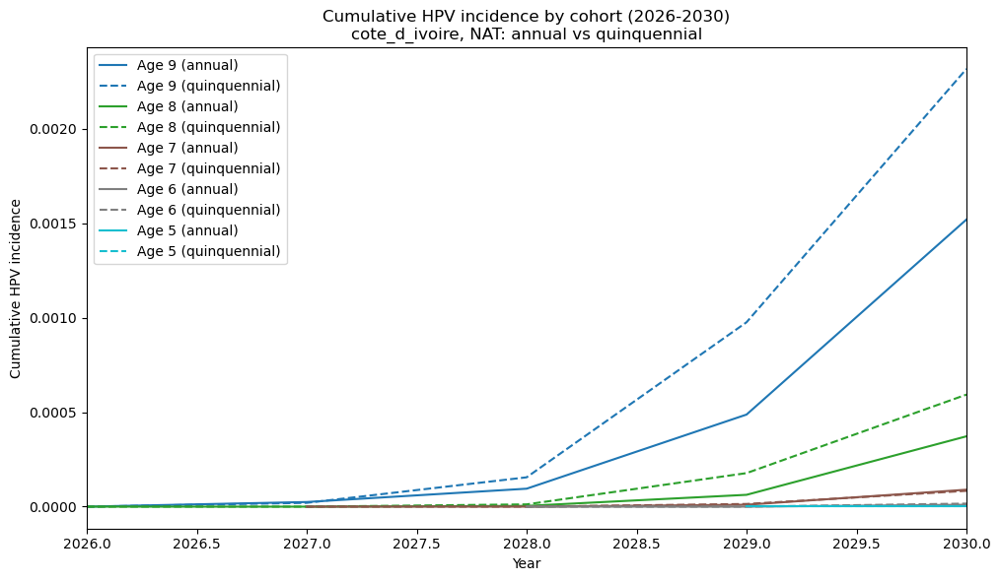

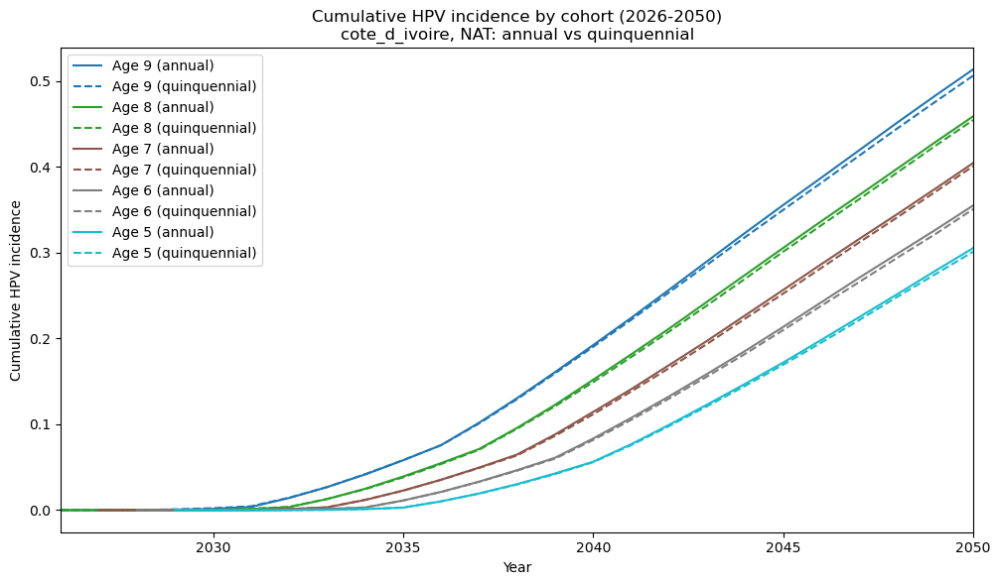

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/4138411286.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

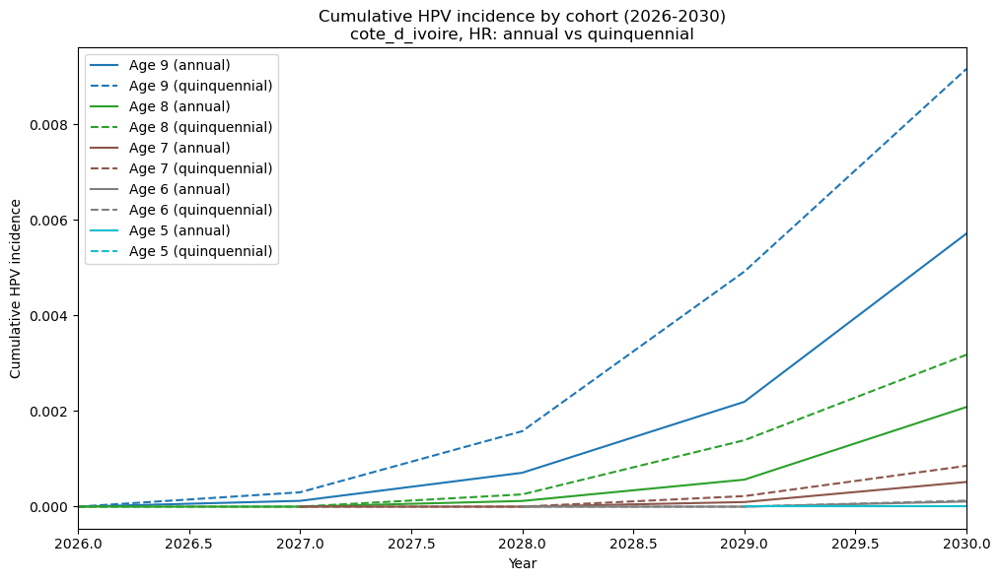

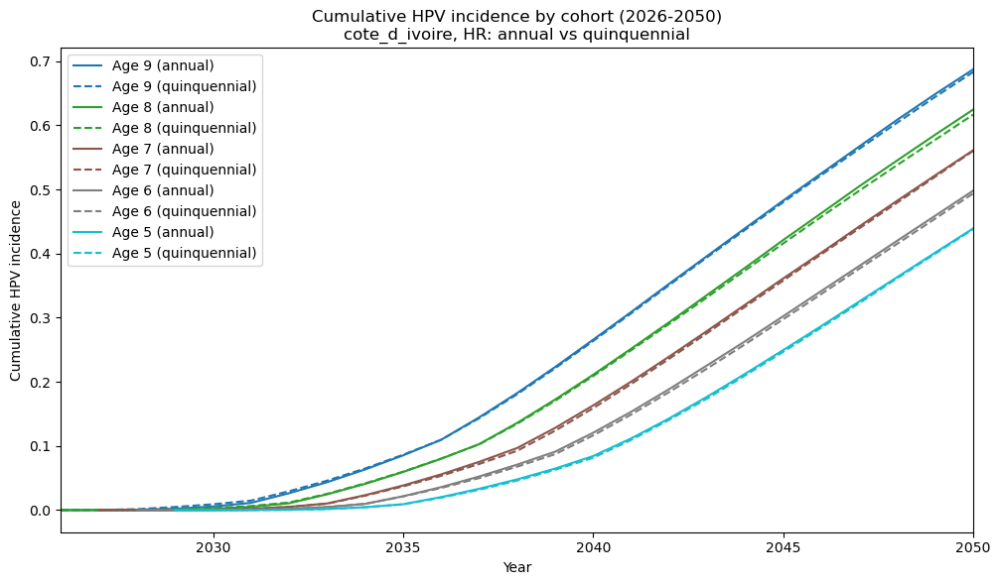

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/4138411286.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

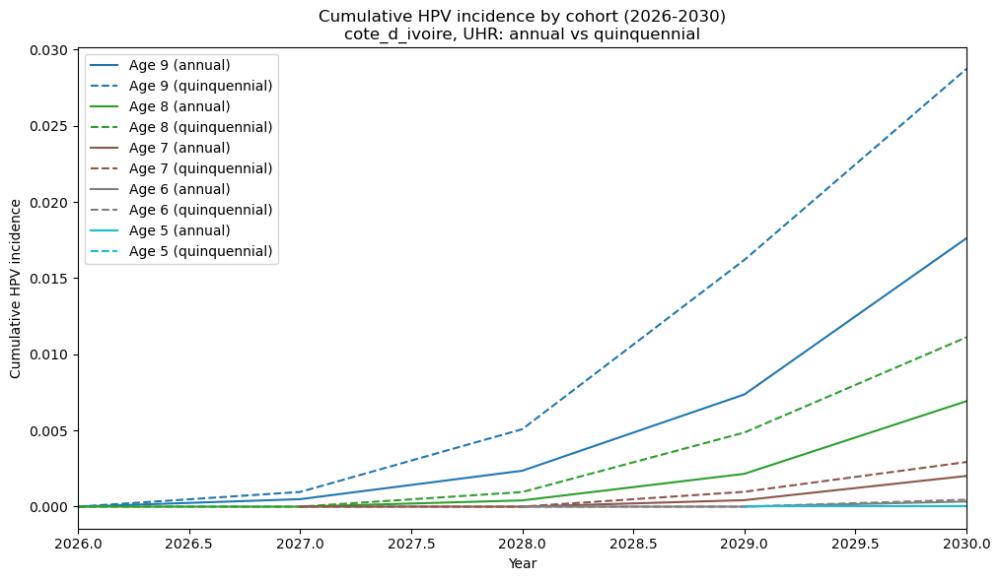

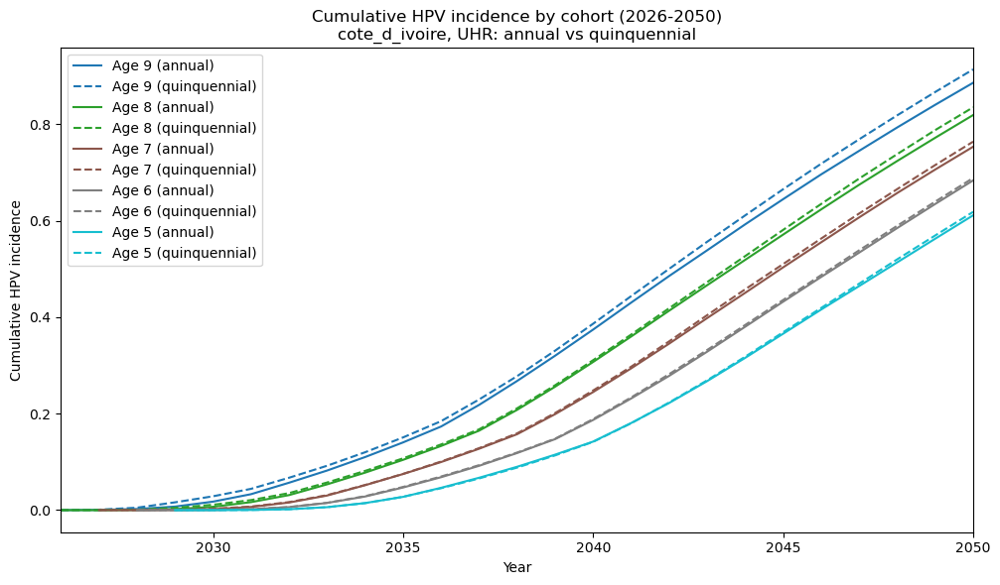

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/4138411286.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

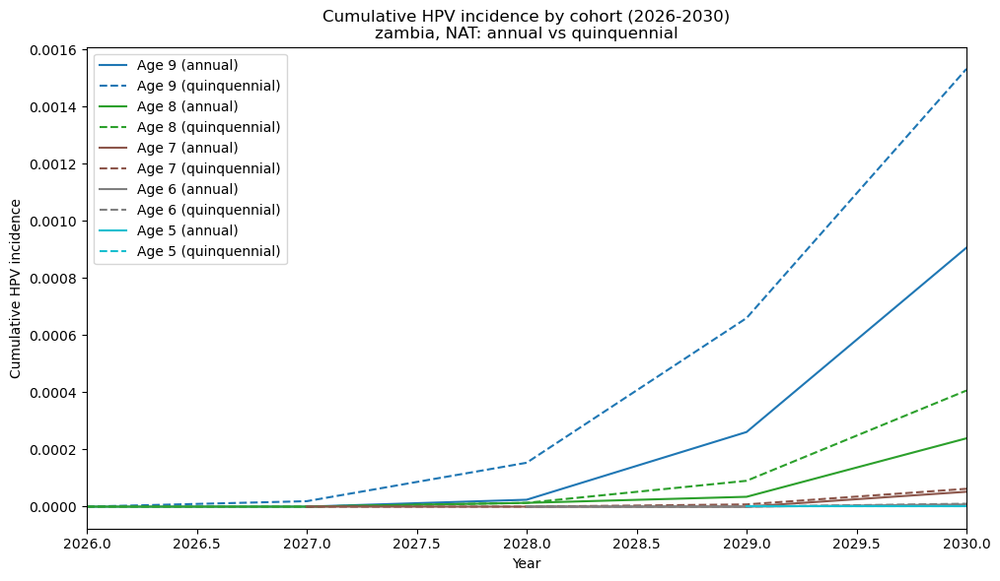

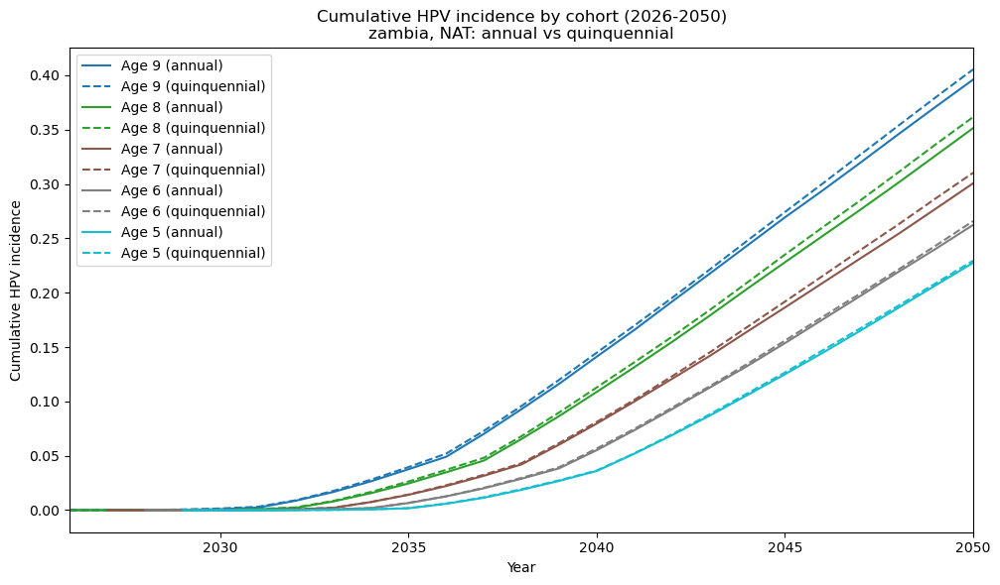

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/4138411286.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

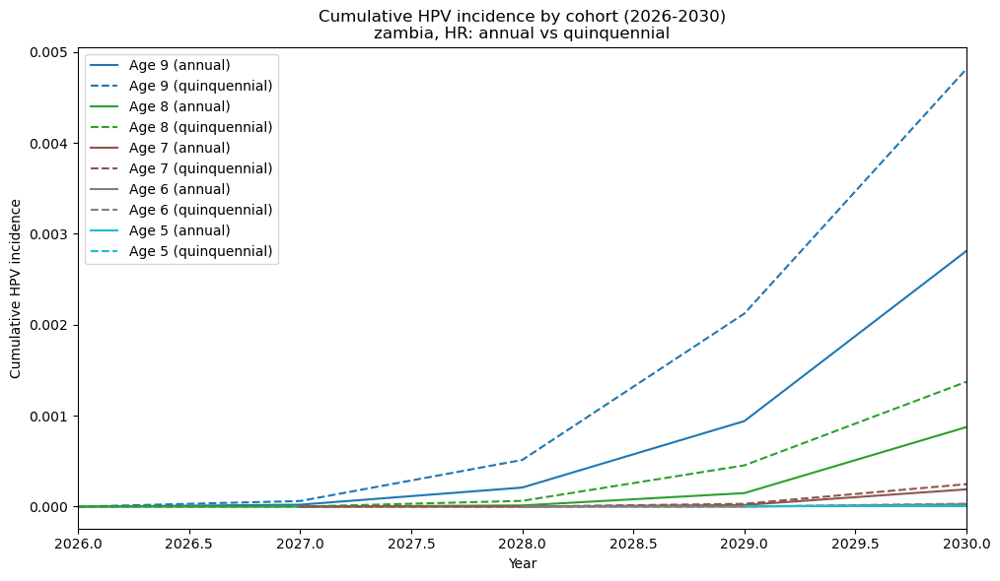

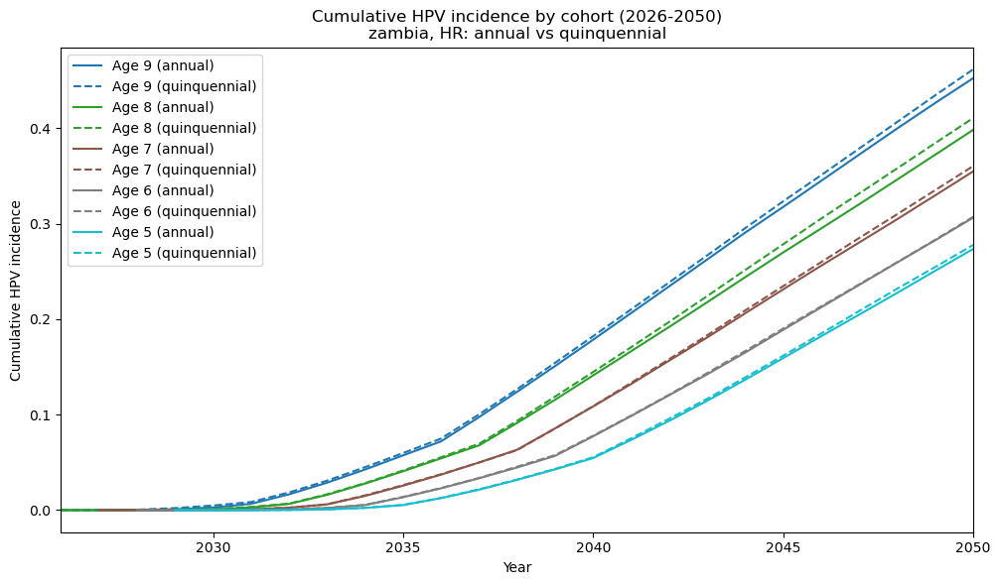

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/4138411286.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

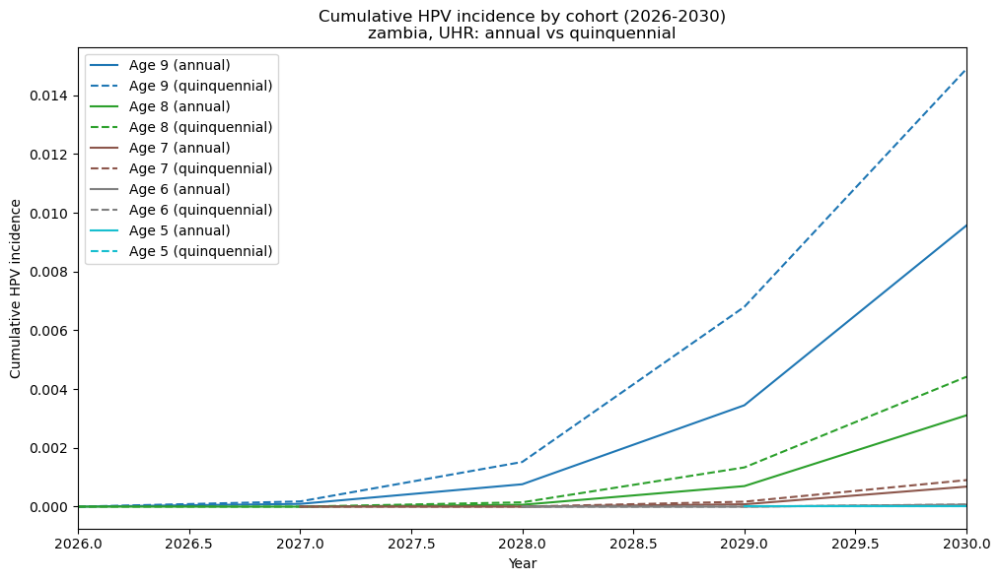

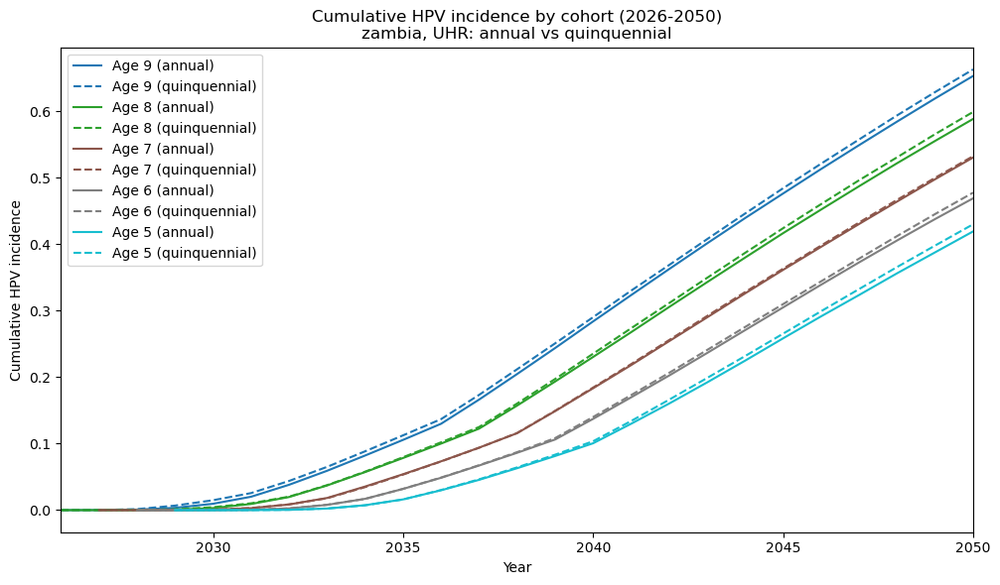

Bad pipe message: %s [b'\xc7\xe8/\xbf\x0f\xc9)\xd0\xf4\x1f\xf7E\x00X\xb1\x7f\xd7\xfb\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00', b'\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x00']
Bad pipe message: %s [b'1\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h']
Bad pipe message: %s [b';X^\x16\xea%\xdf\x00^\x81/8\xbd\xfd#V\xe7Z\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\

In [32]:
# --- Cell 3: Plot Cote d'Ivoire, UHR scenario, annual vs quinquennial vaccination ---
for country in ['cote_d_ivoire', 'zambia']:
    for risk_scenario in ['NAT', 'HR', 'UHR']:
        plot_cohort_cumulative_hpv_incidence(
            country=country,
            risk_scenario=risk_scenario,
            scenario1='vx_annual_9-10',
            scenario2='vx_quinquennial_9-14',
            calibration_source='nov06'
        )


In [9]:
print(list(results_dir.iterdir()))

[PosixPath('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/analysis/../results/vaccination_0p9/cote_d_ivoire_vx_triennial_9-12_NAT_nov06.obj'), PosixPath('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/analysis/../results/vaccination_0p9/cote_d_ivoire_vx_annual_9-10_NAT_nov06.obj'), PosixPath('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/analysis/../results/vaccination_0p9/cote_d_ivoire_vx_biennial_9-11_NAT_nov06.obj'), PosixPath('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/analysis/../results/vaccination_0p9/cote_d_ivoire_vx_quadrennial_9-13_HR_nov06.obj'), PosixPath('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/analysis/../results/vaccination_0p9/cote_d_ivoire_vx_annual_9-10_UHR_nov06.obj'), PosixPath('/Users/kevinmccarthy/Documents/GitHub/hpvsim_faster/hpv_scenarios/analysis/../results/vaccination_0p9/cote_d_ivoire_vx_triennial_9-12_UHR_nov06.obj'), PosixPath('/Users/kevinmccarthy/D

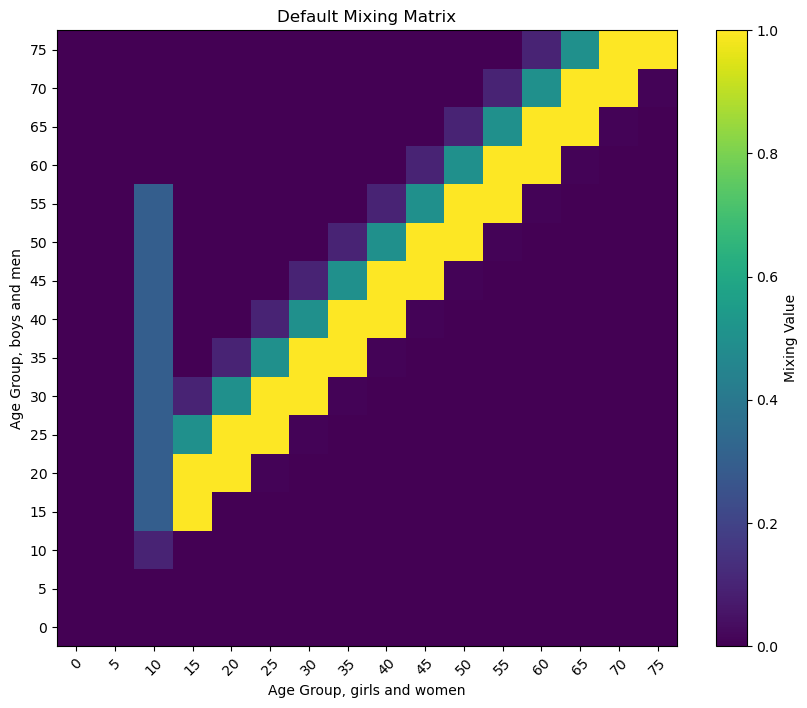

In [16]:
default_mixing_all = np.array([
    #       0,  5, 10, 15, 20,  25,  30,  35,  40,  45,  50,  55,  60,  65,  70,  75
    [0,     0,  0,  0,  0,  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
    [5,     0,  0,  0,  0,  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
    [10,    0,  0,  .1,  0,  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
    [15,    0,  0,  .3,  1,  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
    [20,    0,  0,  .3,  1,  1, .01,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
    [25,    0,  0,  .3, .5,  1,   1, .01,   0,   0,   0,   0,   0,   0,   0,   0,   0],
    [30,    0,  0,  .3, .1, .5,   1,   1, .01,   0,   0,   0,   0,   0,   0,   0,   0],
    [35,    0,  0,  .3,  0, .1,  .5,   1,   1, .01,   0,   0,   0,   0,   0,   0,   0],
    [40,    0,  0,  .3,  0,  0,  .1,  .5,   1,   1, .01,   0,   0,   0,   0,   0,   0],
    [45,    0,  0,  .3,  0,  0,   0,  .1,  .5,   1,   1, .01,   0,   0,   0,   0,   0],
    [50,    0,  0,  .3,  0,  0,   0,   0,  .1,  .5,   1,   1,  .01,  0,   0,   0,   0],
    [55,    0,  0,  .3,  0,  0,   0,   0,   0,  .1,  .5,   1,   1, .01,   0,   0,   0],
    [60,    0,  0,  0,  0,  0,   0,   0,   0,   0,  .1,  .5,   1,   1, .01,   0,   0],
    [65,    0,  0,  0,  0,  0,   0,   0,   0,   0,   0,  .1,  .5,   1,   1, .01,   0],
    [70,    0,  0,  0,  0,  0,   0,   0,   0,   0,   0,   0,  .1,  .5,   1,   1, .01],
    [75,    0,  0,  0,  0,  0,   0,   0,   0,   0,   0,   0,   0,  .1,  .5,   1,   1],
])
plt.figure(figsize=(10, 8))
plt.imshow(default_mixing_all[:,1:], aspect='auto', cmap='viridis')
plt.colorbar(label='Mixing Value')
plt.title('Default Mixing Matrix')
plt.xlabel('Age Group, girls and women')
plt.ylabel('Age Group, boys and men')
plt.gca().invert_yaxis()
tick_labels = default_mixing_all[:, 0].astype(int)
plt.yticks(ticks=np.arange(len(tick_labels)), labels=tick_labels)
plt.xticks(ticks=np.arange(len(tick_labels)), labels=tick_labels, rotation=45)
plt.show()

In [ ]:
import warnings

# --- Cell 2: Define enhanced cohort cumulative plotting function ---
def plot_cohort_cumulative_hpv_incidence_3yr(country, risk_scenario, scenario1, scenario2, calibration_source="nov06"):
    """
    For girls who are ages 9, 8, 7 in 2026, plot cumulative HPV incidence trajectories for each cohort,
    comparing two vaccination scenarios. X-axis is year, color is cohort, solid/dashed is scenario.
    Generates two plots: one to 2028, one to 2050.
    """
    import matplotlib.cm as cm
    cohort_ages_2026 = [9, 8, 7]
    years = np.arange(1960, 2061)
    start_year = 2026
    end_year_early = 2028
    end_year_lifetime = 2050
    age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
    colors = cm.get_cmap('tab10', len(cohort_ages_2026))

    def get_bin_index(age):
        for i in range(len(age_bin_edges)-1):
            if age_bin_edges[i] <= age < age_bin_edges[i+1]:
                return i
        return None

    def get_cohort_cumulative_trajectory(result, age_2026, end_year):
        incidence_by_age = result.results['hpv_incidence_by_age'].values
        traj = []
        cumsum = 0.0
        for offset in range(end_year - start_year + 1):
            age = age_2026 + offset
            year_idx = start_year - 1960 + offset
            bin_idx = get_bin_index(age)
            if bin_idx is not None and bin_idx > 0 and 0 <= year_idx < incidence_by_age.shape[1]:
                cumsum += incidence_by_age[bin_idx, year_idx]
                traj.append((years[year_idx], cumsum))
        return traj

    def load_result(scenario):
        filename = f"{country}_{scenario}_{risk_scenario}_{calibration_source}.obj"
        filepath = results_dir / filename
        if not filepath.exists():
            print(f"File not found: {filename}")
            return None
        return sc.loadobj(filepath)

    result1 = load_result(scenario1)
    result2 = load_result(scenario2)
    if result1 is None or result2 is None:
        print("Missing results for one or both scenarios.")
        return

    # Plot for early years (to 2028)
    plt.figure(figsize=(10, 6))
    for idx, age_2026 in enumerate(cohort_ages_2026):
        traj1 = get_cohort_cumulative_trajectory(result1, age_2026, end_year_early)
        traj2 = get_cohort_cumulative_trajectory(result2, age_2026, end_year_early)
        if traj1:
            plt.plot([t[0] for t in traj1], [t[1] for t in traj1], color=colors(idx), linestyle='-', label=f"Age {age_2026} (annual)")
        if traj2:
            plt.plot([t[0] for t in traj2], [t[1] for t in traj2], color=colors(idx), linestyle='--', label=f"Age {age_2026} (triennial)")
    plt.xlabel("Year")
    plt.ylabel("Cumulative HPV incidence")
    plt.title(f"Cumulative HPV incidence by cohort (2026-2028)\n{country}, {risk_scenario}: annual vs triennial")
    plt.legend()
    plt.tight_layout()
    plt.xlim(start_year, end_year_early)
    plt.show()
    fname = f"cumulative_incidence_2026-2028_1v3_{country}_{risk_scenario}.png"

    # Plot for lifetime (to 2050)
    plt.figure(figsize=(10, 6))
    for idx, age_2026 in enumerate(cohort_ages_2026):
        traj1 = get_cohort_cumulative_trajectory(result1, age_2026, end_year_lifetime)
        traj2 = get_cohort_cumulative_trajectory(result2, age_2026, end_year_lifetime)
        if traj1:
            plt.plot([t[0] for t in traj1], [t[1] for t in traj1], color=colors(idx), linestyle='-', label=f"Age {age_2026} (annual)")
        if traj2:
            plt.plot([t[0] for t in traj2], [t[1] for t in traj2], color=colors(idx), linestyle='--', label=f"Age {age_2026} (triennial)")
    plt.xlabel("Year")
    plt.ylabel("Cumulative HPV incidence")
    plt.title(f"Cumulative HPV incidence by cohort (2026-2050)\n{country}, {risk_scenario}: annual vs triennial")
    plt.legend()
    plt.tight_layout()
    plt.xlim(start_year, end_year_lifetime)
    plt.show()
    fname = f"cumulative_incidence_2026-2050_1v3_{country}_{risk_scenario}.png"

    # To suppress warnings, you can use the warnings module:


/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/2621668687.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

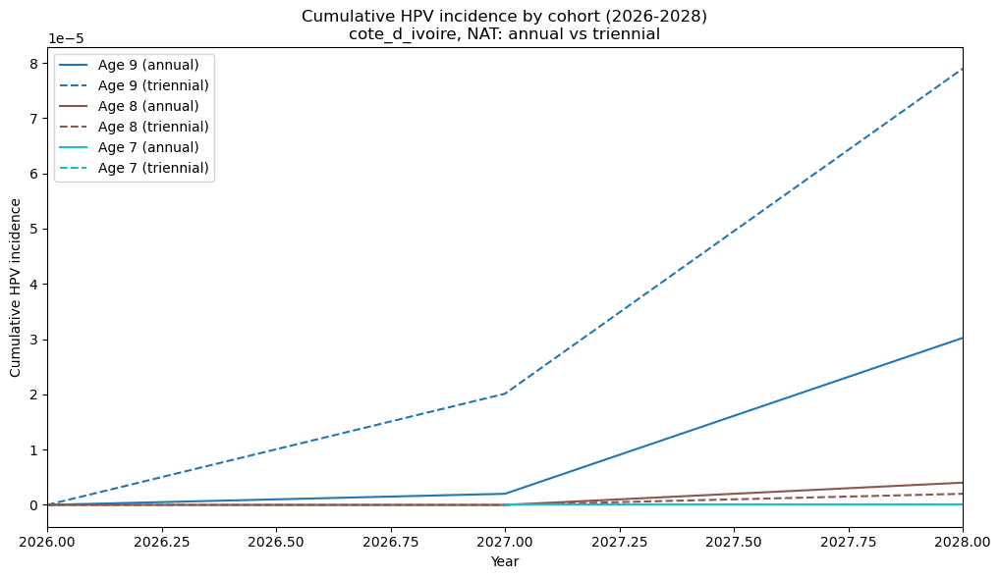

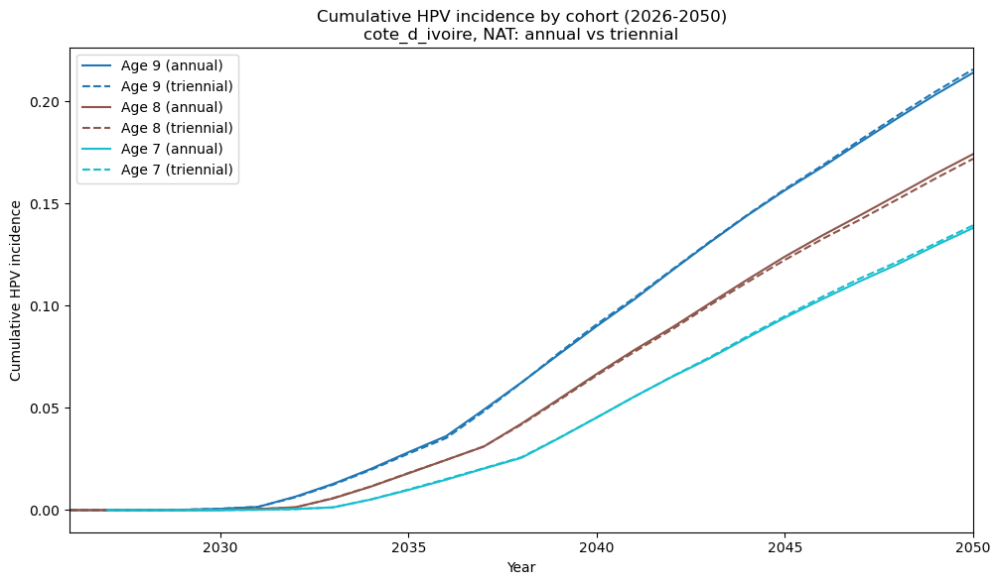

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/2621668687.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

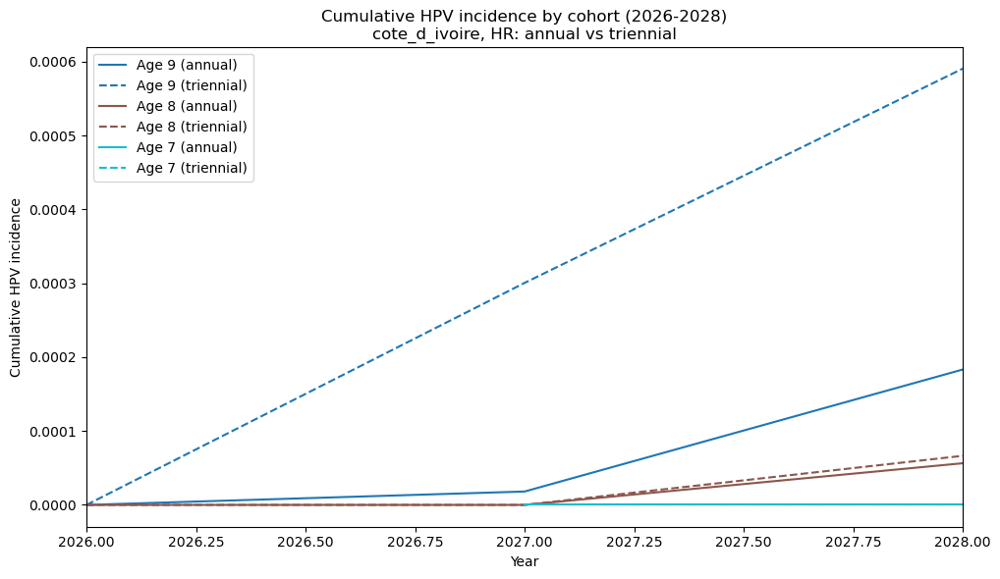

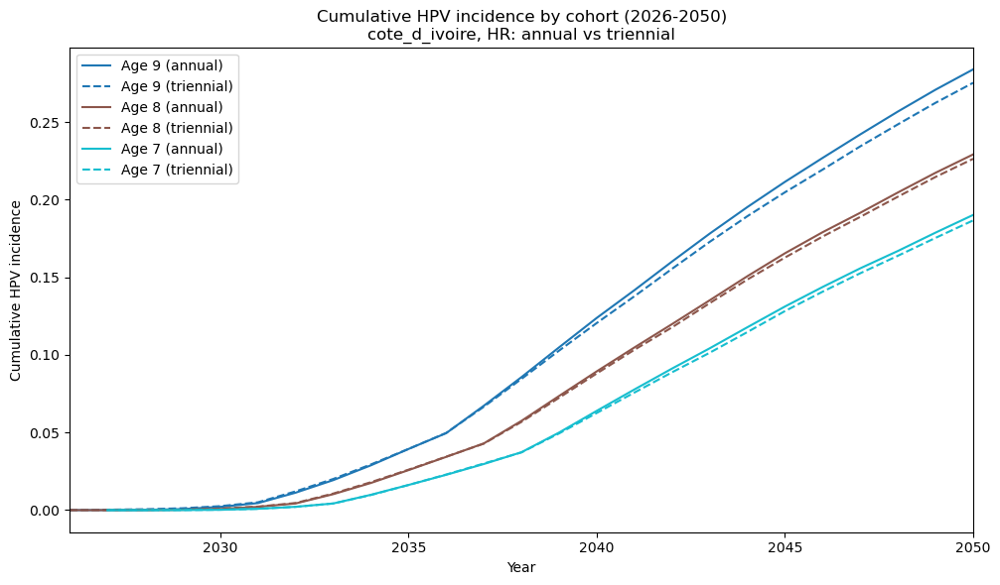

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/2621668687.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

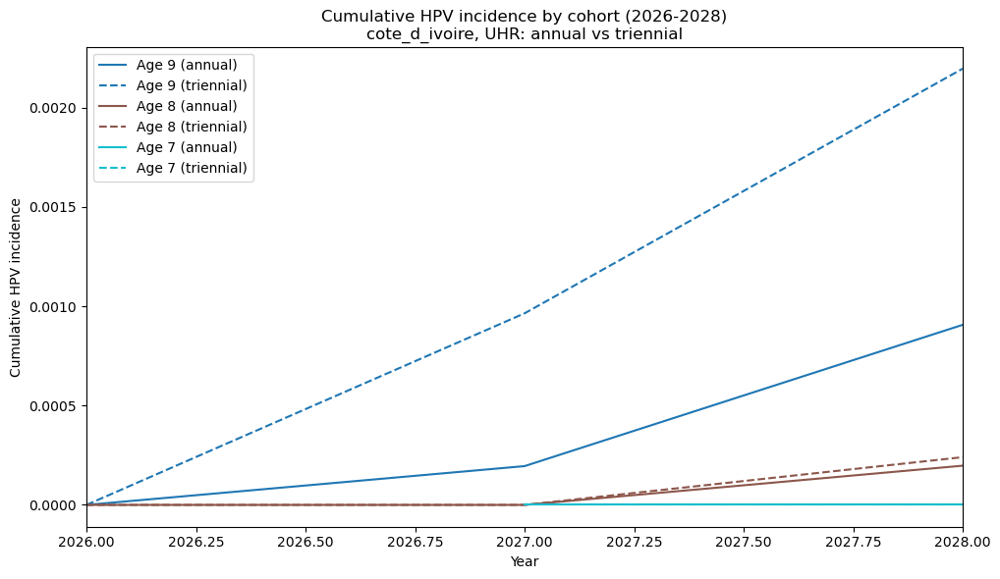

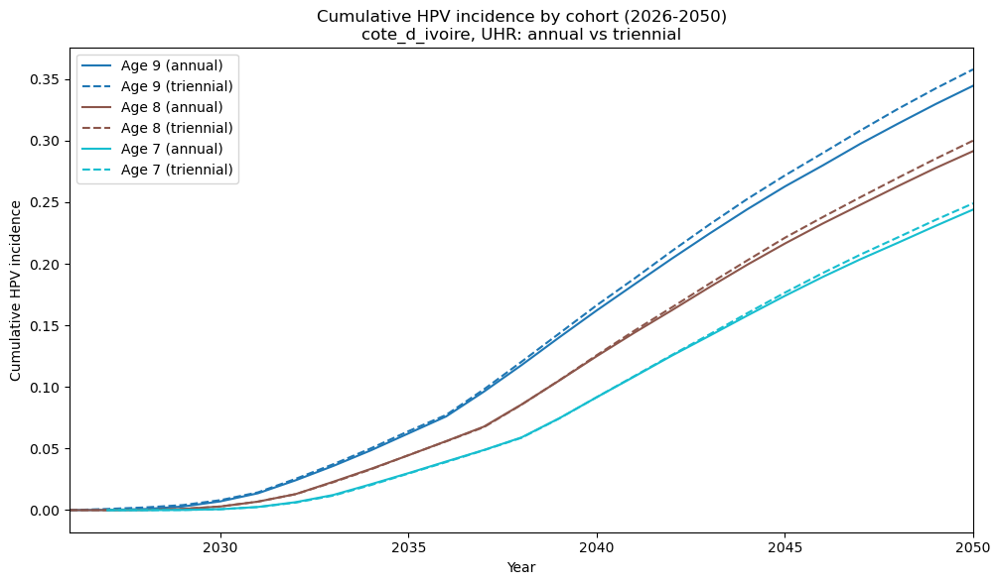

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/2621668687.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

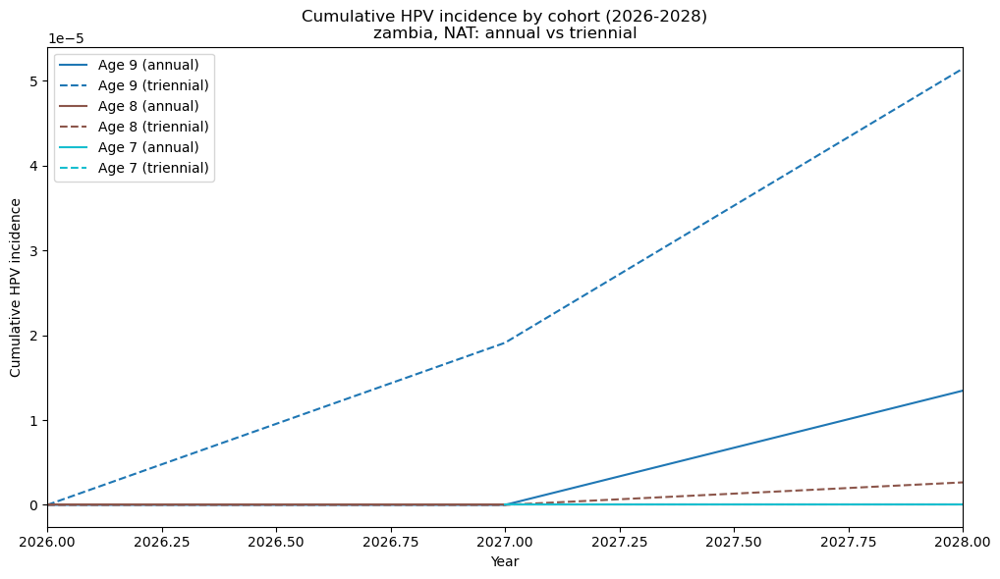

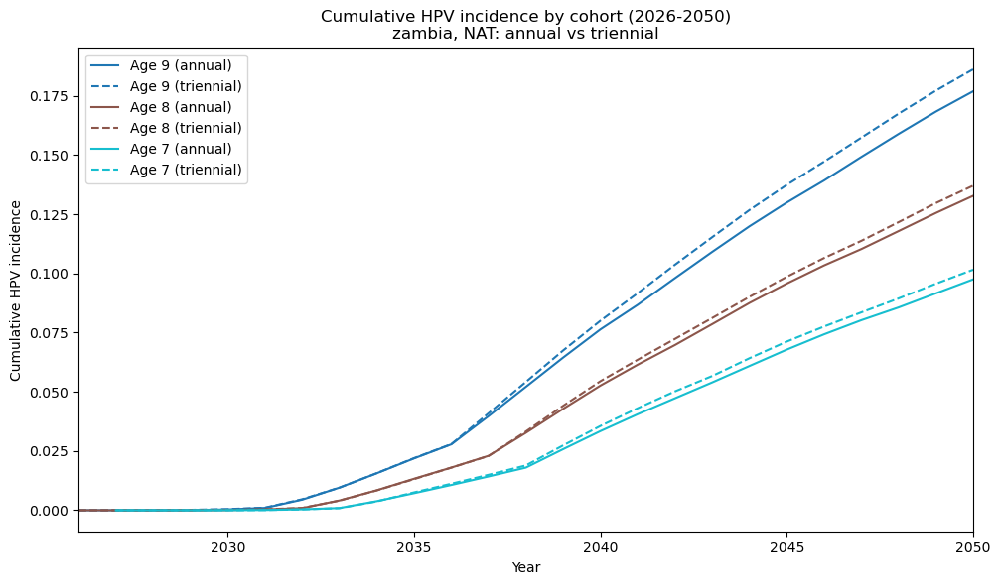

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/2621668687.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

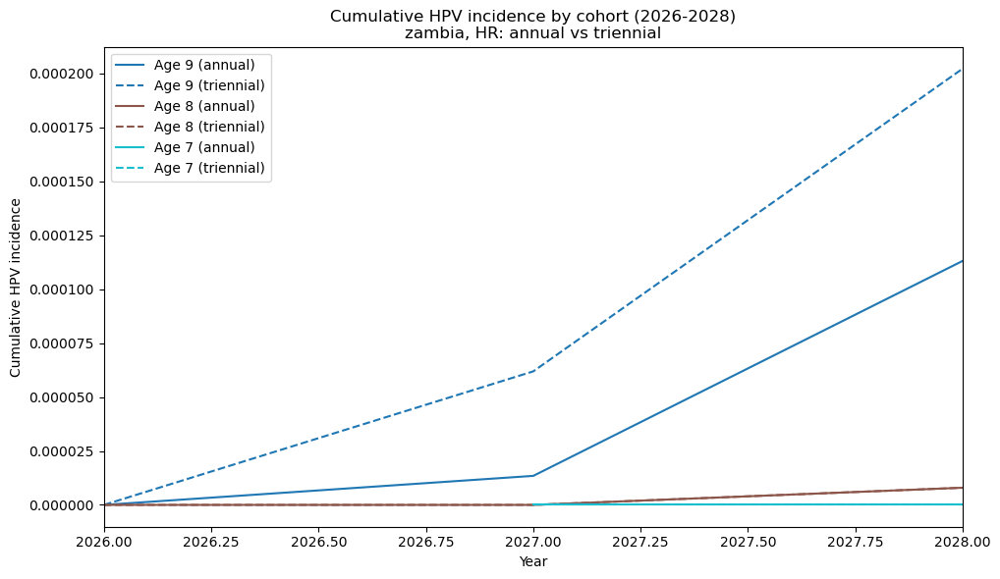

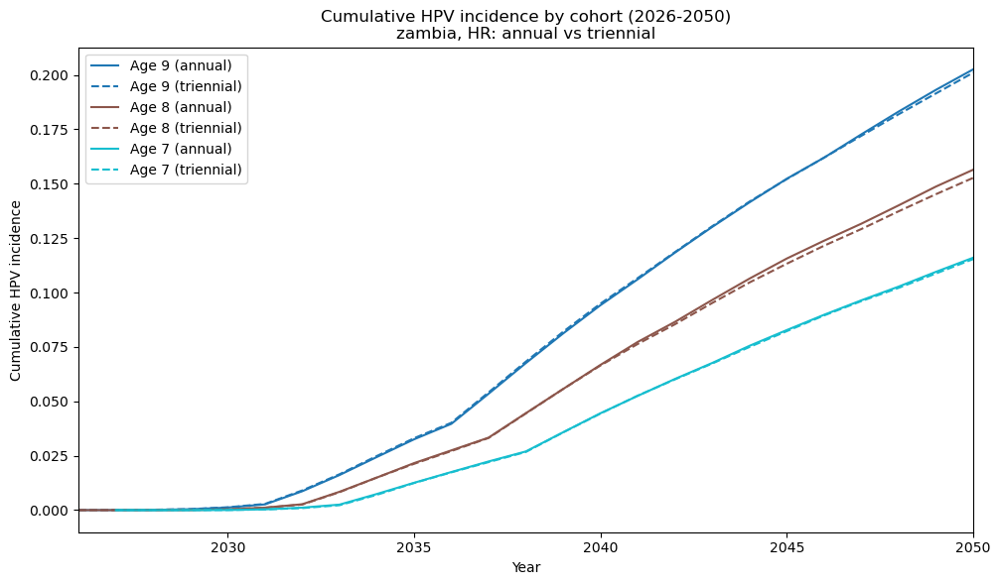

/var/folders/1b/yq6gx3hj51jf_v98kwv057xh0000gn/T/ipykernel_12128/2621668687.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(cohort_ages_2026))
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpick

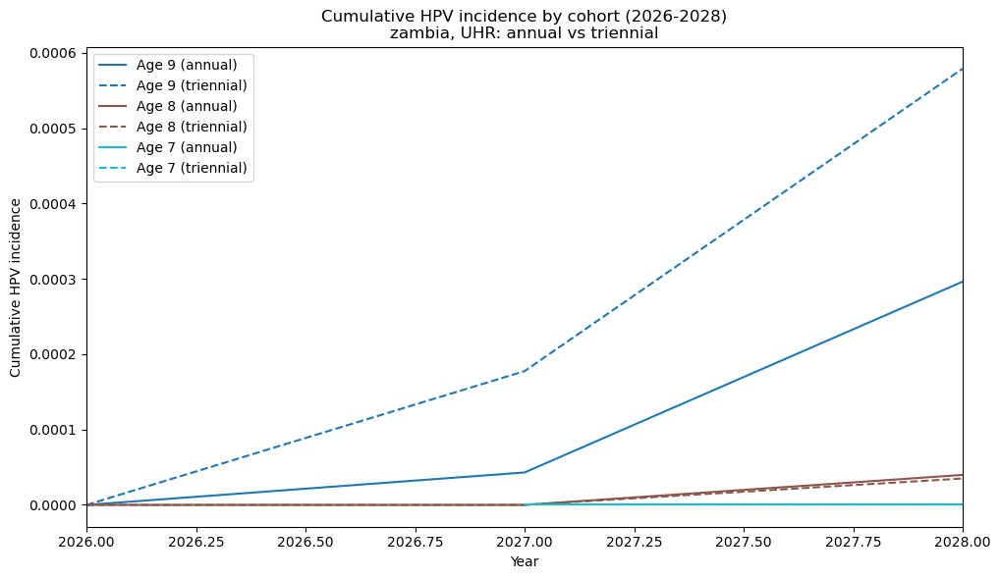

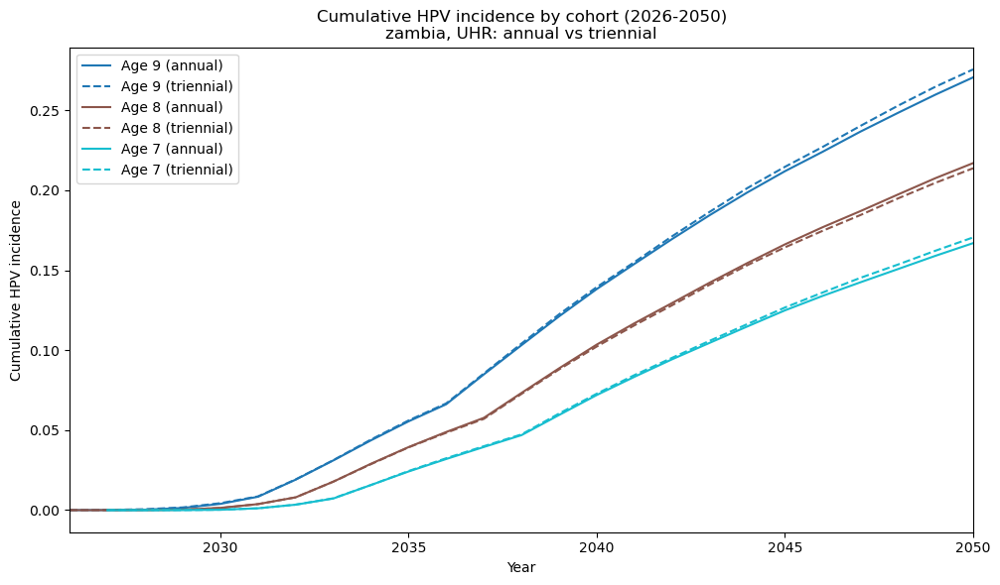

In [29]:
# --- Cell 3: Plot Cote d'Ivoire, UHR scenario, annual vs quinquennial vaccination ---
for country in ['cote_d_ivoire', 'zambia']:
    for risk_scenario in ['NAT', 'HR', 'UHR']:
        plot_cohort_cumulative_hpv_incidence_3yr(
            country=country,
            risk_scenario=risk_scenario,
            scenario1='vx_annual_9-10',
            scenario2='vx_triennial_9-12',
            calibration_source='nov06'
        )

In [43]:
traj1

NameError: name 'traj1' is not defined

In [2]:
age_bin_edges = np.array([0] + list(range(8, 61)) + [70, 80, 90, 100])
start_year = 2026
years = np.arange(1960, 2061)
def get_bin_index(age):
    for i in range(len(age_bin_edges)-1):
        if age_bin_edges[i] <= age < age_bin_edges[i+1]:
            return i
    return None

def get_cohort_cumulative_trajectory(result, age_2026, end_year):
    incidence_by_age = result.results['hpv_incidence_by_age'].values
    traj = []
    cumsum = 0.0
    for offset in range(end_year - start_year + 1):
        age = age_2026 + offset
        year_idx = start_year - 1960 + offset
        bin_idx = get_bin_index(age)
        if bin_idx is not None and bin_idx > 0 and 0 <= year_idx < incidence_by_age.shape[1]:
            cumsum += incidence_by_age[bin_idx, year_idx]
            traj.append((years[year_idx], cumsum))
    return traj


In [3]:
results_dir = project_dir / ".." / "results" / "vaccination_nona_60"
country = 'cote_d_ivoire'
scenario = 'vx_annual_9-10'
risk_scenario = 'HR'
calibration_source = 'nov06'
filename = f"{country}_{scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result = sc.loadobj(filepath)
traj = get_cohort_cumulative_trajectory(result, 7, 2060)

HPVsim 2.2.1 (2025-05-29) — © 2023-2025 by IDM


/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.genotype_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/sciris/sc_fileio.py:184: UnpicklingWarning: Warning, the following errors were encountered during unpickling:
#0. ('analyzers', 'dalys')

In [ ]:
# Define the ages and years of interest
cohort_ages_2026 = list(range(6, 16))  # Ages 6 through 15 in 2026
years_of_interest = [*list(range(2026, 2033)), 2036, 2046, 2056]

# For each cohort, get the cumulative incidence trajectory and extract values for the years of interest
cumulative_incidence_by_cohort = {}

for age_2026 in cohort_ages_2026:
    traj = get_cohort_cumulative_trajectory(result, age_2026, max(years_of_interest))
    # Convert trajectory to a dict for easy lookup
    traj_dict = dict(traj)
    # Extract values for the years of interest
    values = [traj_dict.get(year, None) for year in years_of_interest]
    cumulative_incidence_by_cohort[age_2026] = values

# Convert to DataFrame for easier viewing (optional)
df = pd.DataFrame(cumulative_incidence_by_cohort, index=years_of_interest)
df.index.name = "Year"
df.transpose().to_csv("cumulative_incidence_by_cohort_60.csv")

In [7]:
[*list(range(2026, 2033)), 2036, 2046, 2056]

[2026, 2027, 2028, 2029, 2030, 2031, 2032, 2036, 2046, 2056]

In [13]:
results_dir = project_dir / ".." / "results" / "vaccination_nona_80"
country = 'cote_d_ivoire'
scenario = 'vx_quadrennial_9-13'
risk_scenario = 'HR'
calibration_source = 'nov06'
filename = f"{country}_{scenario}_{risk_scenario}_{calibration_source}.obj"
filepath = results_dir / filename
result = sc.loadobj(filepath)
traj = get_cohort_cumulative_trajectory(result, 7, 2060)

# Define the ages and years of interest
cohort_ages_2026 = list(range(6, 16))  # Ages 6 through 15 in 2026
years_of_interest = [*list(range(2026, 2033)), 2036, 2046, 2056]

# For each cohort, get the cumulative incidence trajectory and extract values for the years of interest
cumulative_incidence_by_cohort = {}

for age_2026 in cohort_ages_2026:
    traj = get_cohort_cumulative_trajectory(result, age_2026, max(years_of_interest))
    # Convert trajectory to a dict for easy lookup
    traj_dict = dict(traj)
    # Extract values for the years of interest
    values = [traj_dict.get(year, None) for year in years_of_interest]
    cumulative_incidence_by_cohort[age_2026] = values

# Convert to DataFrame for easier viewing (optional)
df = pd.DataFrame(cumulative_incidence_by_cohort, index=years_of_interest)
df.index.name = "Year"
df.transpose().to_csv("cumulative_incidence_by_cohort_80_quad.csv")

/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.dalys:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.econ_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/dill/_dill.py:444: UnpicklingWarning: Unpickling error: could not import analyzers.genotype_analyzer:
No module named 'analyzers'
No module named 'analyzers'
  obj = StockUnpickler.load(self)
/Users/kevinmccarthy/anaconda3/envs/env_hpvsim/lib/python3.13/site-packages/sciris/sc_fileio.py:184: UnpicklingWarning: Warning, the following errors were encountered during unpickling:
#0. ('analyzers', 'dalys')